# Jacobian lens from scratch: Qwen3.6-27B

用 MLX 在 Apple Silicon 上把 Anthropic 的
[Jacobian lens](https://www.anthropic.com/research/global-workspace) 從零算一次,
再把論文的實驗搬到 Qwen3.6-27B-4bit 上跑過。

### demo 必講

十分鐘,只到 J-lens 的算法和一個例子。

| 節 | 內容 |
|---|---|
| 1 架構 | 模型長什麼樣子,三張圖 |
| 2 原理 | 兩把尺差在哪一項,「一個 token 的尺」怎麼推出來 |
| 3 算一次 | `The capital of France is`,一次反向傳播,兩把尺並排 |

### 附錄

不在 demo 路徑上,但都是可以重跑的程式碼。

| 附錄 | 內容 |
|---|---|
| A | 整個 $J$ 怎麼算,以及 forward-mode 為什麼不通 |
| B | 不下載那 3.1 GB 也能跑 |
| C | 現算的尺跟釋出的差在哪 |
| D | 擬合範圍的對照 |
| E | 換個語言問同一件事 |
| F | J-space 本體:稀疏非負分解 |
| G | 換掉 J-space 裡的概念 |
| H | 論文的五個 workspace 面向 |
| I | 跑完的樣子、該保留的懷疑、參考資料 |

模型放在 `models/Qwen3.6-27B-4bit`
([mlx-community 版](https://huggingface.co/mlx-community/Qwen3.6-27B-4bit)),
跑在 mlx-vlm 0.6.4。

In [1]:
from mlx_vlm import load
from rich import print


def patch_qwen3_5():
    """mlx-vlm 0.6.4 (#1548) drops the +1.0 shift on qwen3_5 RMSNorm weights, which
    garbles every output. Must run before load()."""
    import mlx_vlm.models.qwen3_5.qwen3_5 as qwen_module
    shifted_suffixes = (".input_layernorm.weight", ".post_attention_layernorm.weight",
                        "model.norm.weight", ".q_norm.weight", ".k_norm.weight")
    if getattr(qwen_module.Model.sanitize, "_patched", False):
        return
    base_sanitize_key = qwen_module.sanitize_key

    def sanitize(self, weights):
        # only checkpoints carrying a multi-token-prediction head need the shift
        needs_shift = any("mtp." in key for key in weights) or any(
            "conv1d.weight" in key and value.shape[-1] != 1
            for key, value in weights.items())
        weights = {key: value for key, value in weights.items() if "mtp." not in key}
        if self.config.text_config.tie_word_embeddings:
            weights.pop("lm_head.weight", None)
        sanitized = {}
        for key, value in weights.items():
            key = base_sanitize_key(key)
            if "conv1d.weight" in key and value.shape[-1] != 1:
                value = value.moveaxis(2, 1)
            if needs_shift and value.ndim == 1 and key.endswith(shifted_suffixes):
                value = value + 1.0
            sanitized[key] = value
        return sanitized

    sanitize._patched = True
    qwen_module.Model.sanitize = sanitize


patch_qwen3_5()

## 1. Qwen3.6-27B 的架構

![Qwen3.6-27B high-level architecture](assets/qwen3_6_27b_vlm_flow.png)

多模態模型,影像和文字各走一條前處理,併成同一串 sequence 之後送進 decoder。

文字這條:tokenizer 把字串切成 token id,再去 embedding 表查出 5120 維向量。

影像這條:切成 16x16 的 patch,每個 patch 過 vision encoder (ViT),再由 PatchMerger
把 2x2 個 patch 併成一個並投影到 5120 維。Qwen 的 vision encoder 接近 SigLIP-2 那一系。

兩邊出來都是 5120 維,拼成同一串之後 decoder 不區分哪些向量來自影像、哪些來自文字。
最後一個位置的輸出過 `lm_head` 變成 248,320 個候選字的分數,取最高分就是下一個 token。

經典論文:
[Attention Is All You Need](https://arxiv.org/abs/1706.03762) (Transformer 本體) ·
[An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929) (ViT) ·
[SigLIP 2](https://arxiv.org/abs/2502.14786) (vision encoder) ·
[Qwen2-VL](https://arxiv.org/abs/2409.12191) (圖文怎麼併、MRoPE 怎麼標位置)

In [2]:
model, processor = load("models/Qwen3.6-27B-4bit")
tokenizer = processor.tokenizer

language_model = model.language_model      # embeddings, decoder stack, output head
decoder = language_model.model             # the 64 blocks
text_config = model.config.text_config

64 層由兩種 block 疊成,每 4 層一組。

In [3]:
for layer_index, layer in enumerate(decoder.layers[:4]):
    kind = ("GatedDeltaNet (linear attention)" if layer.is_linear
            else "Attention (full attention)")
    print(f"layer {layer_index:2d}   {kind}")
print(f"  ...      same pattern x 16  ->  {len(decoder.layers)} layers total")

layer  0   GatedDeltaNet (linear attention)

layer  1   GatedDeltaNet (linear attention)

layer  2   GatedDeltaNet (linear attention)

layer  3   Attention (full attention)

...      same pattern x 16  ->  64 layers total

### 兩種 decoder block

![Qwen3.6-27B architecture](assets/qwen3_6_27b_arch.png)

兩種 block 的外框一樣,都是在 residual stream 上加東西:

```
h  <-  h + mixer(RMSNorm(h))
h  <-  h + FFN(RMSNorm(h))
```

FFN 是 SwiGLU,5120 升到 17408 再壓回 5120。差別在中間的 mixer 怎麼取用前文。

#### Full attention block

標準 causal attention。Qwen 的設定是 24 個 Q head、4 個 KV head(GQA,6 個 Q 共用一組
KV),head_dim 256。另外三個設定:Q 和 K 各自先過 RMSNorm (QK-Norm) 穩住數值;
RoPE 只轉前 64 維,也就是 256 的 25%,其餘維度不帶位置;位置用 MRoPE 分三軸編,
影像 patch 才有二維座標可標。

`q_proj` 的輸出是 `24 x 256 x 2 = 12288` 維,一半當 Q,另一半當 output gate,
這是跟標準實作不同的地方:

```
attn = softmax(Q K^T / sqrt(256)) V
out  = o_proj(attn * sigmoid(gate))
```

attention 的結果先被 sigmoid gate 逐維縮放,再經 `o_proj` (6144 -> 5120) 寫回
residual stream,所以寫進去多少由這一層自己決定。

#### GatedDeltaNet block

GatedDeltaNet 不回頭看整串 sequence,而是維護一個固定大小的 state,邊讀邊更新。
每個 head 的 state 是一個 `128 x 128` 矩陣 `S`(value 維 x key 維),結構上是一本
查找表,`k` 當索引,`v` 當內容。每讀一個 token 做四件事:

```
S  <-  g * S                # decay: 舊資訊按比例衰減
d  <-  beta * (v - S k)     # delta rule: 新 value 減掉查表結果
S  <-  S + d k^T            # write: 只把差額寫回去
y  <-  S q                  # read: 用 q 查表,得到這個位置的輸出
```

中間兩步是 delta rule:寫入前先用 `k` 查一次表裡現有的內容 (`S k`),只把差額
`v - S k` 寫回去,所以同一個 key 重複寫入是覆蓋而不是疊加。

力道由兩個 gate 控制,每個 head 各一個純量:

```
g    = exp(-exp(A_log) * softplus(a + dt_bias))   # decay gate, 落在 (0,1)
beta = sigmoid(b)                                 # write gate
```

`a`、`b` 從當前 token 算出來 (`in_proj_a`、`in_proj_b`,5120 -> 48),`A_log`、`dt_bias`
是學來的參數,所以衰減多少、寫入多強都看內容,不是固定值。

進遞迴之前 q、k、v 先過 depthwise causal conv1d (kernel 4) 加 SiLU,讓相鄰幾個 token
混一下,q 和 k 再各自 normalize 並縮放。出來之後過一個 gated RMSNorm (gate 由
`in_proj_z` 給),最後 `out_proj` (6144 -> 5120) 寫回 residual stream。

Qwen 這邊是 16 個 q/k head、48 個 v head,head_dim 都是 128,所以一層的 state 是
`48 x 128 x 128`,約 79 萬個數字,與 sequence 長度無關。

經典論文:
[RMSNorm](https://arxiv.org/abs/1910.07467) ·
[SwiGLU](https://arxiv.org/abs/2002.05202) ·
[RoPE](https://arxiv.org/abs/2104.09864) ·
[GQA](https://arxiv.org/abs/2305.13245) ·
[Linear Transformers](https://arxiv.org/abs/2006.16236) (linear attention 起點) ·
[Fast Weight Programmers](https://arxiv.org/abs/2102.11174) (delta rule 進到這一系) ·
[Gated Delta Networks](https://arxiv.org/abs/2412.06464) (這個 block 本身) ·
[Mamba-2](https://arxiv.org/abs/2405.21060) (同一系的 state space 做法)

兩者的記憶成本差在會不會隨 sequence 長大。

In [4]:
attention = decoder.layers[3].self_attn
gated_delta_net = decoder.layers[0].linear_attn

# one key and one value vector per token, per layer
key_value_numbers_per_token = 2 * attention.num_key_value_heads * attention.head_dim
# one fixed-size matrix per value head, whatever the length
state_numbers = (gated_delta_net.num_v_heads * gated_delta_net.head_v_dim
                 * gated_delta_net.head_k_dim)

print(f"full attention   {attention.num_attention_heads} query heads / "
      f"{attention.num_key_value_heads} key-value heads x {attention.head_dim}")
print(f"                 cache grows: {key_value_numbers_per_token} numbers "
      f"per token per layer")
print(f"GatedDeltaNet    {gated_delta_net.num_v_heads} value heads x "
      f"{gated_delta_net.head_v_dim} x {gated_delta_net.head_k_dim} state")
print(f"                 fixed: {state_numbers:,} numbers per layer, any length")
print(f"\nbreak-even at {state_numbers // key_value_numbers_per_token} tokens; "
      f"context limit is {text_config.max_position_embeddings:,}")

full attention   24 query heads / 4 key-value heads x 256

cache grows: 2048 numbers per token per layer

GatedDeltaNet    48 value heads x 128 x 128 state

fixed: 786,432 numbers per layer, any length

break-even at 384 tokens; context limit is 262,144

3:1 的排法讓大部分層用固定大小的壓縮記憶,每 4 層插一次 full attention
精確取用前文。

### 輸入長什麼樣

文字和影像各跑一次前處理,印出實際的形狀。

In [5]:
from PIL import Image

text = "The capital of France is"
text_ids = tokenizer.encode(text)

print("TEXT")
print(f"  input     : {text!r}")
print(f"  token ids : {text_ids}")
print(f"  tokens    : {[tokenizer.decode([token]) for token in text_ids]}")

image = Image.open("assets/qwen3_6_27b_arch_residual.png")
vision_inputs = processor.image_processor(images=image, return_tensors="np")
pixel_values = vision_inputs["pixel_values"]
frames, height, width = vision_inputs["image_grid_thw"][0]
merge_size = processor.image_processor.merge_size

print("\nIMAGE")
print(f"  file                  : {image.size[0]}x{image.size[1]} px")
print(f"  grid frames,height,width : {frames},{height},{width}"
      f"  ->  {frames * height * width} patches")
print(f"  pixel_values          : {pixel_values.shape}"
      f"   1536 = temporal 2 x RGB 3 x 16 x 16")
print(f"  after {merge_size}x{merge_size} merge      : "
      f"{(height // merge_size) * (width // merge_size)} vectors into the decoder")

TEXT

input     : 'The capital of France is'

token ids : [760, 6511, 314, 9338, 369]

tokens    : ['The', ' capital', ' of', ' France', ' is']

IMAGE

file                  : 1660x2260 px

grid frames,height,width : 1,142,104  ->  14768 patches

pixel_values          : (14768, 1536)   1536 = temporal 2 x RGB 3 x 16 x 16

after 2x2 merge      : 3692 vectors into the decoder

英文那句是 5 個 token,一張圖攤開是 14768 個 patch,2x2 併完還有 3692 個向量
進 decoder。影像佔的 context 比文字高三個數量級,`merge` 那一步就是為了壓這個數字。

接著走一次 forward 確認模型正常。

In [6]:
import mlx.core as mx

ids = mx.array(tokenizer.encode("The capital of France is"))[None]
logits = language_model(ids).logits
next_token = int(mx.argmax(logits[0, -1]))

print(f"logits     : {logits.shape}")
print(f"next token : {tokenizer.decode([next_token])!r}")

logits     : (1, 5, 248320)

next token : ' Paris'

### 畫圖的設定

每一節的結果都畫成圖,圖下面那幾行 print 是圖上那些點的數值,方便對照。圖上的文字
一律英文,matplotlib 的預設字型沒有中文字。

顏色固定:灰色是基準(logit lens、baseline、原本的答案),藍色是 Jacobian lens
這一側,橘色是跟基準不同的那一條 —— 自己算出來的,或被換進去的。

In [7]:
import matplotlib.pyplot as plt

INK = "#14171a"
LOGIT_COLOR = "#8a9094"       # grey, the baseline ruler
JACOBIAN_COLOR = "#2f6f8f"    # blue, the Jacobian lens
ACCENT_COLOR = "#c1662f"      # orange, whatever differs from the baseline
MUTED_COLOR = "#9aa3a8"       # grey, annotations

plt.rcParams.update({
    "figure.dpi": 130, "savefig.bbox": "tight", "figure.facecolor": "white",
    "font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
    "axes.edgecolor": "#c8cccd", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 6, "axes.labelcolor": "#3f464b",
    "xtick.color": "#5a6166", "ytick.color": "#5a6166",
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": "#e8ebec", "grid.linewidth": 0.7,
    "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 1.6, "lines.markersize": 4,
})


def panel(axes, title="", xlabel="", ylabel="", ymax=None):
    """One look for every panel: title on the left, horizontal grid only."""
    if title:
        axes.set_title(title, loc="left", color=INK)
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.grid(axis="y")
    axes.set_axisbelow(True)
    if ymax is not None:
        axes.set_ylim(0, ymax)
    return axes


print("plot style ready")

plot style ready

## 2. 兩把尺的原理

模型最後吐出來的分數是

$$\text{logits} \;=\; W_U \,\mathrm{norm}(h_L)$$

$h_L$ 是最後一層的 residual,$\mathrm{norm}$ 是 RMSNorm,$W_U$ 是 $248320 \times 5120$
的 unembedding 矩陣。

### logit lens

拿同一個讀出頭去讀中間第 $\ell$ 層:

$$\text{LogitLens}(h_\ell) \;=\; W_U\,\mathrm{norm}(h_\ell)$$

這等於假設 $\ell$ 之後每一層都什麼都不做,把 $h_\ell$ 當成 $h_L$ 用。實際上 $h_\ell$
還要經過 $64-\ell$ 層才會變成 $h_L$。

### Jacobian lens

把「後面那些層」當成一個函數 $h_L = f_\ell(h_\ell)$,在 $h_\ell$ 附近一階展開:

$$h_L \;\approx\; J_\ell\, h_\ell, \qquad
J_\ell \;=\; \frac{\partial h_L}{\partial h_\ell}$$

讀出改成

$$\text{JLens}(h_\ell) \;=\; W_U\,\mathrm{norm}(J_\ell\, h_\ell)$$

兩把尺只差中間那個 $J_\ell$,logit lens 是把它當成單位矩陣。$J_\ell$ 的尺寸是
$5120 \times 5120$。residual 每個 token 位置各有一個 $h_\ell$,所以這裡的 $J_\ell$ 是
某一個位置對某一個位置的偏微分,位置怎麼取在附錄 A。

### 一個 token 的尺

單看某個 token $t$ 的分數。設 $w_t$ 是 $W_U$ 的第 $t$ 列,$\gamma$ 是 RMSNorm 的權重:

$$\text{score}_t
\;=\; \big\langle w_t,\; \mathrm{norm}(J h) \big\rangle
\;=\; \frac{\big\langle w_t \odot \gamma,\; J h \big\rangle}{\mathrm{rms}(J h)}
\;=\; \frac{\big\langle J^{\top}(w_t \odot \gamma),\; h \big\rangle}{\mathrm{rms}(J h)}$$

第二個等號把 RMSNorm 拆開,除以 $\mathrm{rms}$ 是一個純量,逐維乘 $\gamma$ 可以搬到
另一邊。第三個等號是把 $J$ 移到內積的左邊。定義

$$v_t \;=\; J^{\top}(w_t \odot \gamma)$$

分數就是 $h$ 跟 $v_t$ 的內積,再除以一個正的純量。$v_t$ 是「token $t$ 的尺」,一個
5120 維向量,$h$ 在它上面投影多少,就是這個 token 在 J-lens 下的分數。

這個式子決定了實作怎麼寫。$J^{\top}u$ 是「向量乘 Jacobian 的轉置」,正是反向傳播在算
的東西,所以拿一把尺只要一次 backward pass,不必把 $J$ 湊出來。

## 3. 算一次

In [8]:
from mlx_vlm.models.qwen3_5.language import (
    _create_qwen3_5_attention_mask, _create_qwen3_5_ssm_mask)

model_dtype = decoder.norm.weight.dtype
hidden_size = text_config.hidden_size
layer_count = len(decoder.layers)


def encode(text):
    return mx.array(tokenizer.encode(text))[None]


def prepare_layer_inputs(h):
    """What a layer needs besides the residual. The model builds these itself, but from
    cache.offset, so calling layers with cache=None means supplying them here. The two
    block types take different masks. position_ids has three rows because Qwen encodes
    position on three MRoPE axes (time, height, width); text uses token order on all
    three."""
    attention_mask = _create_qwen3_5_attention_mask(h, None)
    state_space_mask = _create_qwen3_5_ssm_mask(h, None)
    token_order = mx.arange(h.shape[1])[None, None, :]
    position_ids = mx.tile(token_order, (3, 1, 1))
    return attention_mask, state_space_mask, position_ids


def set_linear_attention_train(mode):
    """Evaluation mode runs a Metal kernel mx.vjp cannot differentiate; train mode runs
    plain operations. Needed for the Jacobian."""
    for layer in decoder.layers:
        if layer.is_linear:
            layer.linear_attn.train(mode)


def residuals(ids):
    """The residual stream after each of the 64 layers."""
    set_linear_attention_train(False)
    h = decoder.embed_tokens(ids)
    attention_mask, state_space_mask, position_ids = prepare_layer_inputs(h)
    per_layer = []
    for layer in decoder.layers:
        h = layer(h, mask=(state_space_mask if layer.is_linear else attention_mask),
                  cache=None, position_ids=position_ids, position_embeddings=None)
        per_layer.append(h)
    return per_layer


def readout(h):
    """The model's own output head: RMSNorm, then unembed to vocabulary scores."""
    return language_model.lm_head(decoder.norm(h))


residual_by_layer = residuals(encode("The capital of France is"))
print(f"{len(residual_by_layer)} residuals, each "
      f"{tuple(residual_by_layer[0].shape)} = (batch, tokens, hidden_size)")

64 residuals, each (1, 5, 5120) = (batch, tokens, hidden_size)

### logit lens 讀一遍

同一個讀出頭套在第 44 層之後的每一層上。前面 44 層答案的機率全是 0,不用看。
上界取 62,因為後面要拿來比的那條釋出的 lens 只到第 62 層。

In [9]:
prompt = "The capital of France is"
ids = encode(prompt)
residual_by_layer = residuals(ids)
last_position = ids.shape[1] - 1

answer_token = int(mx.argmax(readout(residual_by_layer[-1])[0, last_position]))
ANSWER = tokenizer.decode([answer_token])
LAYERS = list(range(44, 63))

logit_probability, logit_top_token = [], []
for layer_index in LAYERS:
    scores = readout(
        residual_by_layer[layer_index][0, last_position]).astype(mx.float32)
    logit_probability.append(float(mx.softmax(scores)[answer_token]))
    logit_top_token.append(tokenizer.decode([int(mx.argmax(scores))]))


def first_layer_where(values, test):
    return next((layer for layer, value in zip(LAYERS, values) if test(value)), None)


logit_top_layer = first_layer_where(logit_top_token, lambda token: token == ANSWER)
print(f"{prompt!r} -> {ANSWER!r}")
print(f"logit lens: top-1 becomes {ANSWER!r} at L{logit_top_layer}, "
      f"p(answer) passes 0.5 at "
      f"L{first_layer_where(logit_probability, lambda p: p > 0.5)}")
print("  p(answer) " + " ".join(f"{p:.3f}" for p in logit_probability))

'The capital of France is' -> ' Paris'

logit lens: top-1 becomes ' Paris' at L55, p(answer) passes 0.5 at L57

p(answer) 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.001 0.088 0.237 0.520 0.922 0.856 0.858 
0.940 0.247

### 一次反向傳播,一把尺

`mx.vjp(f, x, u)` 算的是 $u^{\top}\partial f/\partial x$。要的 $v_t = J^{\top}(w_t \odot
\gamma)$ 就是 $u = w_t \odot \gamma$ 的那一次呼叫。cotangent 放在最後一個位置,因為要讀
的是那個位置的分數。

兩個 MLX 的地方要繞。GatedDeltaNet 在 eval 模式走一個不可微的 Metal kernel,得切到
train 模式才會走純 ops 的版本;那個版本內部呼叫 `mx.async_eval`,在 `mx.vjp` 的 trace
裡是非法的,得暫時擋掉。

In [10]:
import contextlib
import time

output_head = language_model.lm_head
gamma = decoder.norm.weight.astype(mx.float32)   # the RMSNorm gain, one per dimension


@contextlib.contextmanager
def no_async_eval():
    """The GatedDeltaNet scan calls mx.async_eval, illegal inside an mx.vjp trace."""
    original = mx.async_eval
    mx.async_eval = lambda *args, **kwargs: None
    try:
        yield
    finally:
        mx.async_eval = original


def unembed_row(token):
    """w_t, one row of W_U, dequantized out of the 4-bit output head."""
    index = mx.array([token])
    return mx.dequantize(output_head.weight[index], output_head.scales[index],
                         output_head.biases[index], group_size=output_head.group_size,
                         bits=output_head.bits)[0].astype(mx.float32)


def forward_from(ids, delta, source_layer):
    """A forward pass with delta added to the residual right after source_layer.
    Differentiating it by delta at zero differentiates h_final by h_source."""
    h = decoder.embed_tokens(ids)
    attention_mask, state_space_mask, position_ids = prepare_layer_inputs(h)
    for layer_index, layer in enumerate(decoder.layers):
        h = layer(h, mask=(state_space_mask if layer.is_linear else attention_mask),
                  cache=None, position_ids=position_ids, position_embeddings=None)
        if layer_index == source_layer:
            h = h + delta
    return h


def ruler(token, layer_index, ids, position):
    """v_t = J^T (w_t * gamma) at one position, from a single backward pass."""
    cotangent = mx.zeros((1, ids.shape[1], hidden_size), dtype=mx.float32)
    cotangent[0, position] = unembed_row(token) * gamma
    delta = mx.zeros((1, ids.shape[1], hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, layer_index),
            (delta,), (cotangent.astype(model_dtype),))
        v = gradient[0, position].astype(mx.float32)
        mx.eval(v)
    set_linear_attention_train(False)
    return v


start = time.perf_counter()
ruler_at_55 = ruler(answer_token, 55, ids, last_position)
residual_at_55 = residual_by_layer[55][0, last_position].astype(mx.float32)

print(f"v for {ANSWER!r} at L55: {tuple(ruler_at_55.shape)}, one backward pass, "
      f"{time.perf_counter() - start:.0f}s")
print(f"<v, h> = {float(ruler_at_55 @ residual_at_55):.1f}   "
      f"a score, up to the shared 1/rms(J h)")

v for ' Paris' at L55: (5120,), one backward pass, 1s

<v, h> = 40.2   a score, up to the shared 1/rms(J h)

### 為什麼還是要一個預先算好的 lens

一次反向傳播給一個方向。要畫出 `p(answer)` 這條曲線,softmax 的分母得掃過詞表全部
248320 個 token,那需要 $J h$ 的 5120 個座標,湊齊要 5120 次反向傳播。整條 $J$ 因此由
官方預先算好釋出([jlens-qwen36](https://github.com/WeZZard/jlens-qwen36),3.1 GB 的
npz),兩把尺並排那張圖用的是那一份。

釋出的那條在 1000 個 prompt、位置 $\ge 16$ 上平均過,現算的是這一句、這一個位置。
條件不同,所以下面那個 cosine 不會接近 1,附錄 C 對齊條件之後再量一次。

In [11]:
lens_file = mx.load("models/Qwen3.6-27B-4bit/jlens.npz")
released_lens = {layer: lens_file[f"J_{layer}"] for layer in
                 [int(x) for x in lens_file["__source_layers__"].tolist()]}
prompt_count = int(lens_file["__n_prompts__"].tolist()[0])


def transport(h, layer_index):
    """J @ h: move a layer's residual into the final-residual basis."""
    J = released_lens[layer_index]
    return (h.astype(J.dtype) @ J.T).astype(model_dtype)


# section 2's formula, computed both ways on the released J
jacobian_times_h = transport(residual_at_55[None, None], 55)[0, 0].astype(mx.float32)
root_mean_square = float(
    mx.sqrt(mx.mean(jacobian_times_h * jacobian_times_h) + decoder.norm.eps))
by_hand = float((unembed_row(answer_token) * gamma)
                @ jacobian_times_h / root_mean_square)
from_readout = float(readout(jacobian_times_h)[answer_token])

released_ruler = ((unembed_row(answer_token) * gamma)
                  @ released_lens[55].astype(mx.float32))
cosine = float(ruler_at_55 @ released_ruler
               / (mx.linalg.norm(ruler_at_55) * mx.linalg.norm(released_ruler)))

print(f"released lens: {len(released_lens)} layers, "
      f"averaged over {prompt_count} prompts")
print(f"score of {ANSWER!r} at L55:  by hand {by_hand:.3f}   "
      f"from readout {from_readout:.3f}")
print(f"cosine(computed here, released) = {cosine:.3f}")

released lens: 63 layers, averaged over 1000 prompts

score of ' Paris' at L55:  by hand 20.419   from readout 20.419

cosine(computed here, released) = 0.385

### 兩把尺並排

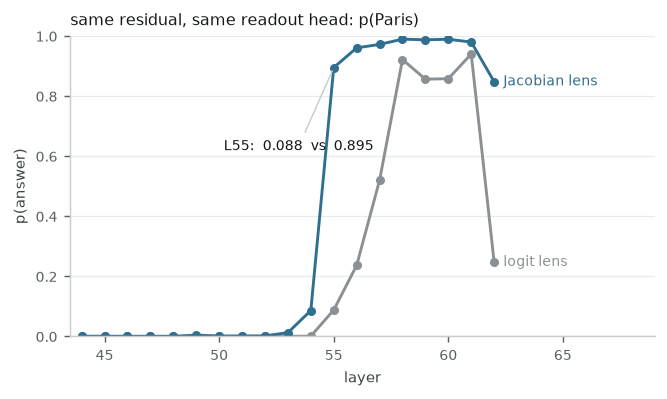

logit    0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.001 0.088 0.237 0.520 0.922 0.856 0.858 
0.940 0.247

jacobian 0.000 0.000 0.000 0.000 0.000 0.004 0.001 0.001 0.001 0.012 0.086 0.895 0.961 0.972 0.990 0.987 0.989 
0.980 0.848

top-1 becomes ' Paris' at L55 (jacobian) and L55 (logit)

p(answer) passes 0.5 at L55 (jacobian) and L57 (logit)

at L55: 0.088 vs 0.895, at L62: 0.247 vs 0.848

In [12]:
jacobian_probability, jacobian_top_token = [], []
for layer_index in LAYERS:
    scores = readout(transport(residual_by_layer[layer_index][0, last_position],
                               layer_index)).astype(mx.float32)
    jacobian_probability.append(float(mx.softmax(scores)[answer_token]))
    jacobian_top_token.append(tokenizer.decode([int(mx.argmax(scores))]))

figure, axes = plt.subplots(figsize=(5.8, 3.0))
axes.plot(LAYERS, logit_probability, color=LOGIT_COLOR, marker="o")
axes.plot(LAYERS, jacobian_probability, color=JACOBIAN_COLOR, marker="o")
axes.text(LAYERS[-1] + 0.4, logit_probability[-1], "logit lens",
          color=LOGIT_COLOR, va="center", fontsize=8)
axes.text(LAYERS[-1] + 0.4, jacobian_probability[-1], "Jacobian lens",
          color=JACOBIAN_COLOR, va="center", fontsize=8)
index_of_55 = LAYERS.index(55)
axes.annotate(f"L55:  {logit_probability[index_of_55]:.3f}"
              f"  vs  {jacobian_probability[index_of_55]:.3f}",
              xy=(55, jacobian_probability[index_of_55]), xytext=(50.2, 0.62),
              color=INK, fontsize=8,
              arrowprops=dict(arrowstyle="-", color="#c8cccd", lw=0.8))
axes.set_xlim(43.5, 69)
panel(axes, f"same residual, same readout head: p({ANSWER.strip()})", "layer",
      "p(answer)", 1.0)
plt.show()

print("  logit    " + " ".join(f"{p:.3f}" for p in logit_probability))
print("  jacobian " + " ".join(f"{p:.3f}" for p in jacobian_probability))
print(f"  top-1 becomes {ANSWER!r} at "
      f"L{first_layer_where(jacobian_top_token, lambda t: t == ANSWER)} "
      f"(jacobian) and L{logit_top_layer} (logit)")
print(f"  p(answer) passes 0.5 at "
      f"L{first_layer_where(jacobian_probability, lambda p: p > 0.5)} "
      f"(jacobian) and "
      f"L{first_layer_where(logit_probability, lambda p: p > 0.5)} (logit)")
print(f"  at L55: {logit_probability[index_of_55]:.3f} vs "
      f"{jacobian_probability[index_of_55]:.3f}, "
      f"at L62: {logit_probability[-1]:.3f} vs {jacobian_probability[-1]:.3f}")

### 讀出來的

同一個 residual、同一個讀出頭,兩把尺在中段給出的機率差一個數量級,機率過半的層數差
兩層。top-1 翻成 `' Paris'` 的層數兩者相同,所以這個例子的差距在信心。換個語言問同一
件事,層數的差距會拉開很多,附錄 E。

$\ell$ 越靠後,$J_\ell$ 越接近單位矩陣,兩把尺應該收在一起。圖的尾端兩條還是分開的,
因為釋出的 lens 平均過,跟這一句自己的 $J$ 有距離,附錄 C 量的就是這個距離。

$J$ 是某一個輸入、某一個位置附近的一階近似,換個 prompt 就是另一個 $J$,而平均會抹掉
個別 prompt 的結構。讀得到也不代表模型在用它,要證明因果得動手去改,那是附錄 G 和 H 的事。

## 附錄

### A. 整個 $J$ 怎麼算,以及 forward-mode 為什麼不通

cotangent 換成 one-hot $e_i$,反向傳播給的就是 $J$ 的第 $i$ 列。要整個 $J$ 就是 5120 個
one-hot,一次批 64 個的話 80 批。訓練時的 `loss.backward()` 是同一個呼叫,cotangent 放
的是 1.0。

釋出的 lens 對位置取平均,算的是
$\mathbb{E}_{t' \le t}\big[\partial h_{L,t} / \partial h_{\ell,t'}\big]$,
並且跳過前 16 個位置(BOS 和格式 token,讀出那裡是雜訊)。

$J h$ 是矩陣乘向量,理論上 forward-mode 微分一次就給,不必湊矩陣也不必下載。這條路
在 MLX 上不通,因為 fast RMSNorm、RoPE、attention 都是 `CustomKernel`,只寫了
reverse 規則,
`mx.jvp` 會直接丟 `[Primitive::jvp] Not implemented for CustomKernel`。

In [13]:
SKIP_FIRST_POSITIONS = 16


def jacobian_rows(ids, source_layer, row_count):
    """The first row_count rows of J, averaged over positions the way the lens was."""
    sequence_length = ids.shape[1]
    valid_positions = mx.array(
        list(range(SKIP_FIRST_POSITIONS, sequence_length - 1)), dtype=mx.int32)
    one_hot = (mx.arange(hidden_size)[None, :]
               == mx.arange(row_count)[:, None]).astype(mx.float32)
    position_mask = (mx.arange(sequence_length)[None, :]
                     == valid_positions[:, None]).any(axis=0).astype(mx.float32)
    cotangent = (one_hot[:, None, :] * position_mask[None, :, None]).astype(model_dtype)
    delta = mx.zeros((row_count, sequence_length, hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, source_layer),
            (delta,), (cotangent,))
        rows = mx.take(gradient, valid_positions, axis=1).mean(axis=1).astype(mx.float32)
        mx.eval(rows)
    set_linear_attention_train(False)
    return rows


long_prompt = ("The history of the Roman Empire spans several centuries and includes "
               "many emperors, wars, and cultural achievements that shaped the "
               "ancient world.")

start = time.perf_counter()
computed_rows = jacobian_rows(
    mx.array(tokenizer.encode(long_prompt)[:48])[None], 54, 64)
elapsed = time.perf_counter() - start
computed_flat = computed_rows.reshape(-1)
released_flat = released_lens[54].astype(mx.float32)[:64].reshape(-1)

print(f"J[L54] first 64 of {hidden_size} rows: {tuple(computed_rows.shape)} in "
      f"{elapsed:.0f}s  ->  whole matrix about "
      f"{elapsed * hidden_size / 64 / 60:.0f} min per layer")
print(f"diagonal J[0,0] = {float(computed_rows[0, 0]):.3f}   "
      f"row norm = {float(mx.linalg.norm(computed_rows[0])):.3f}")
print(f"cosine(these rows, released lens) = "
      f"{float((computed_flat @ released_flat) / (mx.linalg.norm(computed_flat) * mx.linalg.norm(released_flat))):.3f}")

J[L54] first 64 of 5120 rows: (64, 5120) in 25s  ->  whole matrix about 33 min per layer

diagonal J[0,0] = 0.949   row norm = 1.136

cosine(these rows, released lens) = 0.894

### B. 沒有那 3.1 GB 也能跑

要的是名次而不是機率的話,反向傳播就夠。候選集取模型最後一層的 top-8,每一層做一次
批次 VJP 拿到這 8 個 token 的尺,看答案排第幾。名次對 $1/\mathrm{rms}(Jh)$ 那個純量
免疫 —— 分母是同一個正數,不影響排序。

現算的那條比釋出的更早把答案排到第一。局部的 $J$ 只描述這一句,沒有被一千個 prompt
的平均稀釋,這能解釋它為什麼更早。單一 prompt、單一位置的排名也更容易是雜訊,而這張
圖分不出是哪一種。

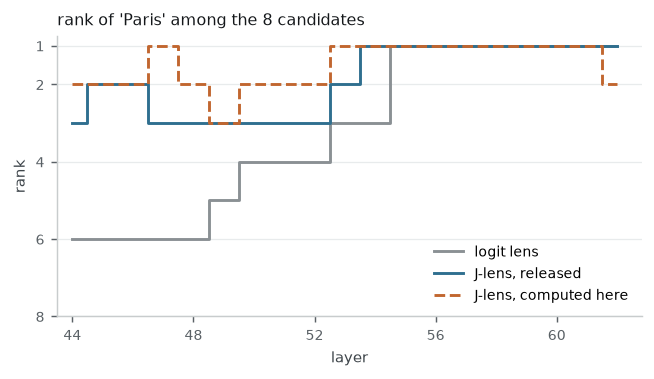

candidates: [' Paris', ' not', '\n\n', ' London', ' the', ' a', ' __', ' Berlin']

whole curve, 19 layers, no released lens: 50s

logit     reaches rank 1 at L55

released  reaches rank 1 at L54

computed  reaches rank 1 at L47

In [14]:
CANDIDATES = [int(token) for token in mx.argsort(
    -readout(residual_by_layer[-1])[0, last_position].astype(mx.float32))[:8].tolist()]
candidate_cotangents = mx.stack(
    [unembed_row(token) * gamma for token in CANDIDATES], axis=0)


def rank_computed_here(layer_index):
    """Rank of the answer among CANDIDATES, from one batched backward pass."""
    cotangent = mx.zeros((8, ids.shape[1], hidden_size), dtype=mx.float32)
    cotangent[:, last_position, :] = candidate_cotangents
    delta = mx.zeros((8, ids.shape[1], hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, layer_index),
            (delta,), (cotangent.astype(model_dtype),))
        scores = (gradient[:, last_position, :].astype(mx.float32)
                  @ residual_by_layer[layer_index][0, last_position].astype(mx.float32))
        mx.eval(scores)
    set_linear_attention_train(False)
    return 1 + int(mx.sum(scores > scores[0]))


def rank_among_candidates(all_scores):
    scores = all_scores[mx.array(CANDIDATES)]
    return 1 + int(mx.sum(scores > scores[0]))


start = time.perf_counter()
rank_computed, rank_released, rank_logit = [], [], []
for layer_index in LAYERS:
    h = residual_by_layer[layer_index][0, last_position]
    rank_computed.append(rank_computed_here(layer_index))
    rank_released.append(
        rank_among_candidates(readout(transport(h, layer_index)).astype(mx.float32)))
    rank_logit.append(rank_among_candidates(readout(h).astype(mx.float32)))
elapsed = time.perf_counter() - start

figure, axes = plt.subplots(figsize=(5.8, 2.8))
# all three converge on rank 1, so end labels would sit on top of each other
axes.step(LAYERS, rank_logit, where="mid", color=LOGIT_COLOR, label="logit lens")
axes.step(LAYERS, rank_released, where="mid", color=JACOBIAN_COLOR,
          label="J-lens, released")
axes.step(LAYERS, rank_computed, where="mid", color=ACCENT_COLOR, ls="--",
          label="J-lens, computed here")
axes.invert_yaxis()
axes.set_yticks([1, 2, 4, 6, 8])
axes.set_xlim(43.5, 62.8)
axes.set_xticks(range(44, 63, 4))
axes.legend(loc="lower right")
panel(axes, f"rank of {ANSWER.strip()!r} among the 8 candidates", "layer", "rank")
plt.show()

print(f"candidates: {[tokenizer.decode([token]) for token in CANDIDATES]}")
print(f"whole curve, {len(LAYERS)} layers, no released lens: {elapsed:.0f}s")
for name, ranks in (("logit", rank_logit), ("released", rank_released),
                    ("computed", rank_computed)):
    first_layer = next((layer for layer, rank in zip(LAYERS, ranks) if rank == 1), None)
    print(f"  {name:<9} reaches rank 1 at L{first_layer}")

### C. 現算的尺跟釋出的差在哪

釋出的 lens 對位置平均過。把現算的也照同樣方式平均,cosine 就跳上來,第 3 節那個偏低的
cosine 來自條件不同。

短 prompt 沒辦法做這件事,5 個 token 裡位置 $\ge 16$ 的一個都沒有。前面墊一段無關的文字
之後才有位置可平均。

In [15]:
FILLER = ("Here are some notes about geography that provide background context "
          "for the question that follows this introductory sentence. ")


def ruler_averaged(token, layer_index, ids):
    """The same ruler, averaged over positions the way the released lens was fitted."""
    sequence_length = ids.shape[1]
    valid_positions = mx.array(
        list(range(SKIP_FIRST_POSITIONS, sequence_length - 1)), dtype=mx.int32)
    position_mask = (mx.arange(sequence_length)[None, :]
                     == valid_positions[:, None]).any(axis=0).astype(mx.float32)
    cotangent_row = unembed_row(token) * gamma
    cotangent = (cotangent_row[None, :] * position_mask[:, None])[None].astype(model_dtype)
    delta = mx.zeros((1, sequence_length, hidden_size), dtype=model_dtype)
    set_linear_attention_train(True)
    with no_async_eval():
        (_,), (gradient,) = mx.vjp(
            lambda perturbation: forward_from(ids, perturbation, layer_index),
            (delta,), (cotangent,))
        v = mx.take(gradient[0], valid_positions, axis=0).mean(axis=0).astype(mx.float32)
        mx.eval(v)
    set_linear_attention_train(False)
    return v


CHECK_LAYERS = [54, 58, 62]
print(f"cosine(computed here, released), for {ANSWER!r}")
print(f"{'prompt':<8} {'tokens':>7} {'averaged':>9} "
      + " ".join(f"{'L' + str(layer):>8}" for layer in CHECK_LAYERS))
for label, text in (("short", prompt), ("padded", FILLER + prompt)):
    prompt_ids = encode(text)
    for averaged in (False, True):
        if averaged and prompt_ids.shape[1] <= SKIP_FIRST_POSITIONS + 1:
            print(f"{label:<8} {prompt_ids.shape[1]:>7} {'yes':>9}   "
                  f"no position >= {SKIP_FIRST_POSITIONS} to average over")
            continue
        cosines = []
        for layer in CHECK_LAYERS:
            v = (ruler_averaged(answer_token, layer, prompt_ids) if averaged
                 else ruler(answer_token, layer, prompt_ids,
                            prompt_ids.shape[1] - 1))
            released = (unembed_row(answer_token) * gamma) @ released_lens[layer].astype(
                mx.float32)
            cosines.append(float(v @ released
                                 / (mx.linalg.norm(v) * mx.linalg.norm(released))))
        print(f"{label:<8} {prompt_ids.shape[1]:>7} "
              f"{'yes' if averaged else 'no':>9} "
              + " ".join(f"{value:>8.3f}" for value in cosines))

cosine(computed here, released), for ' Paris'

prompt    tokens  averaged      L54      L58      L62

short          5        no    0.337    0.340    0.729

short          5       yes   no position >= 16 to average over

padded        24        no    0.320    0.338    0.717

padded        24       yes    0.835    0.882    0.974

L55 那一行:同一條 residual、同一顆讀出頭,logit lens 給 0.09,Jacobian lens
給 0.90。top-1 也差一層,Jacobian lens 在 L55 就讀到 `' Paris'`。

### D. 擬合範圍的對照

公開 lens 在擬合時會跳過每條 prompt 的前 16 個 position,
[issue #5](https://github.com/anthropics/jacobian-lens/issues/5) 就在講這件事。
上面那條 prompt 只有 5 個 token,讀的是 position 4,落在 lens 沒擬合過的區間。
所以要在前面墊一段無關的話,把要讀的位置推到 16 以後,看結果還在不在。

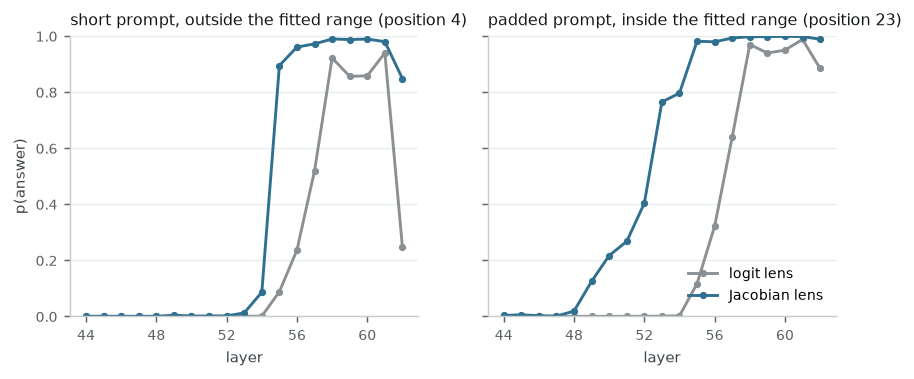

short prompt, outside the fitted range (position 4)

L50   logit 0.000   jacobian 0.001

L53   logit 0.000   jacobian 0.012

L54   logit 0.001   jacobian 0.086

L55   logit 0.088   jacobian 0.895

...

L53   logit 0.001   jacobian 0.765

L54   logit 0.002   jacobian 0.796

L55   logit 0.117   jacobian 0.982

L56   logit 0.321   jacobian 0.979

L58   logit 0.970   jacobian 0.998

In [16]:
FILLER = ("Here are some notes about geography that provide background context "
          "for the question that follows this introductory sentence. ")


def lens_curves(prompt, layers):
    ids = encode(prompt)
    residual_by_layer = residuals(ids)
    last_position = ids.shape[1] - 1
    ans = int(mx.argmax(readout(residual_by_layer[-1])[0, last_position].astype(mx.float32)))
    lg, jc = [], []
    for layer_index in layers:
        h = residual_by_layer[layer_index][0, last_position]
        lg.append(float(mx.softmax(readout(h).astype(mx.float32))[ans]))
        jc.append(float(mx.softmax(readout(transport(h, layer_index)).astype(mx.float32))[ans]))
    return last_position, lg, jc


LS = [layer_index for layer_index in range(44, layer_count) if layer_index in released_lens]
CASES = [("short prompt, outside the fitted range",
          "The capital of France is"),
         ("padded prompt, inside the fitted range",
          FILLER + "The capital of France is")]

fig, axes = plt.subplots(1, 2, figsize=(7.6, 2.8), sharey=True)
out = []
for ax, (title, prompt) in zip(axes, CASES):
    pos, lg, jc = lens_curves(prompt, LS)
    out.append((title, pos, lg, jc))
    ax.plot(LS, lg, color=LOGIT_COLOR, marker="o", ms=3)
    ax.plot(LS, jc, color=JACOBIAN_COLOR, marker="o", ms=3)
    ax.set_xticks(range(44, 63, 4))
    panel(ax, f"{title} (position {pos})", "layer", "", 1.0)
axes[0].set_ylabel("p(answer)")
axes[1].legend(["logit lens", "Jacobian lens"], loc="lower right")
plt.show()

for title, pos, lg, jc in out:
    print(f"{title} (position {pos})")
    for layer_index, a, b in zip(LS, lg, jc):
        if layer_index in (50, 53, 54, 55, 56, 58):
            print(f"   L{layer_index}   logit {a:.3f}   jacobian {b:.3f}")

### E. 換個語言問同一件事

同一個問題用中文問。

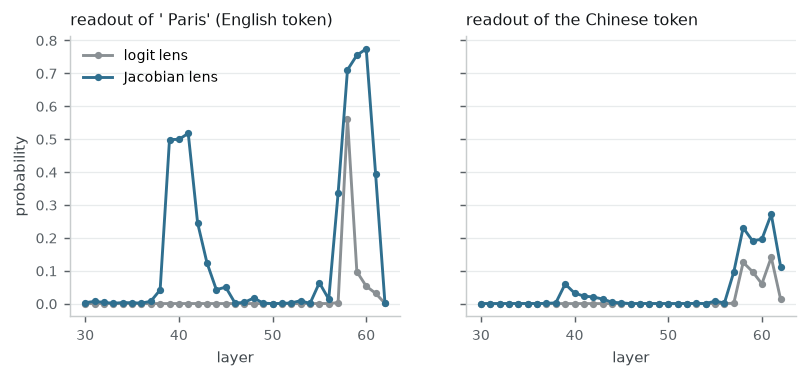

'法国的首都是'   output top-1 = '哪个'

jacobian top-3                          logit top-3

L40  ' Paris' ' city' ' cities'                '...' ' ____' '____'

L44  '____' ' city' ' cities'                  '...' '____' '<u'

L48  '____' ' ______' '___'                    '<u' '____' ' ____'

L52  '？' '____' '___'                          ' gì' '什么' '哪个'

L56  '哪里' '哪个' ' Paris'                        '哪里' '哪个' '否'

L60  ' Paris' '巴黎' 'Paris'                     '哪个' '哪里' '巴黎'

In [17]:
PARIS = {11751, 57590, 109705}   # ' Paris', 'Paris', and the Chinese token
ZH_PARIS = 109705


def lens_trace(prompt, layers, k=3):
    ids = encode(prompt)
    residual_by_layer = residuals(ids)
    last_position = ids.shape[1] - 1
    print(f"{prompt!r}   output top-1 = "
          f"{tokenizer.decode([int(mx.argmax(readout(residual_by_layer[-1])[0, last_position]))])!r}")
    print("        jacobian top-3                          logit top-3")
    for layer_index in layers:
        if layer_index not in released_lens:
            continue
        h = residual_by_layer[layer_index][0, last_position]
        j = mx.argsort(-readout(transport(h, layer_index)).astype(mx.float32))[:k]
        g = mx.argsort(-readout(h).astype(mx.float32))[:k]
        js = " ".join(f"{tokenizer.decode([int(t)])!r}" for t in j)
        gs = " ".join(f"{tokenizer.decode([int(t)])!r}" for t in g)
        print(f"  L{layer_index:2d}  {js:40s}  {gs}")


ZH = "法国的首都是"
ids = encode(ZH)
residual_by_layer = residuals(ids)
last_position = ids.shape[1] - 1
LS = [layer_index for layer_index in range(30, layer_count) if layer_index in released_lens]

curves = {}
for name, tok in (("en", 11751), ("zh", ZH_PARIS)):
    for lens in ("logit", "jacobian"):
        curves[(name, lens)] = []
    for layer_index in LS:
        h = residual_by_layer[layer_index][0, last_position]
        curves[(name, "logit")].append(
            float(mx.softmax(readout(h).astype(mx.float32))[tok]))
        curves[(name, "jacobian")].append(
            float(mx.softmax(readout(transport(h, layer_index)).astype(mx.float32))[tok]))

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), sharey=True)
for ax, (name, title) in zip(axes, (("en", "readout of ' Paris' (English token)"),
                                    ("zh", "readout of the Chinese token"))):
    ax.plot(LS, curves[(name, "logit")], color=LOGIT_COLOR, marker="o", ms=3)
    ax.plot(LS, curves[(name, "jacobian")], color=JACOBIAN_COLOR, marker="o", ms=3)
    panel(ax, title, "layer", "", None)
axes[0].set_ylabel("probability")
axes[0].legend(["logit lens", "Jacobian lens"], loc="upper left")
plt.show()

lens_trace(ZH, range(40, 62, 4))

中文問句,Jacobian lens 在 L40 就把英文的 `' Paris'` 排第一,同一層的 logit lens
還是 `'...'` 這類碎片。中文的 `'巴黎'` 要到 L60 才進 top-3,而模型表面上要說的下一個字是
`'哪个'`,在把句子接完(「法国的首都是哪个城市」)。

這條 prompt 的順序是答案先以英文浮出來,中文晚得多,表面還在造句。方向跟 Anthropic 在
[On the Biology of a Large Language Model](https://transformer-circuits.pub/2025/attribution-graphs/biology.html)
講的多語言迴路一致,不過一條 prompt 證不了「不綁語言的概念空間」,只能說看到的順序
跟那個說法不衝突。

換幾個語言,看 `Paris` 最早在哪一層進 top-5。

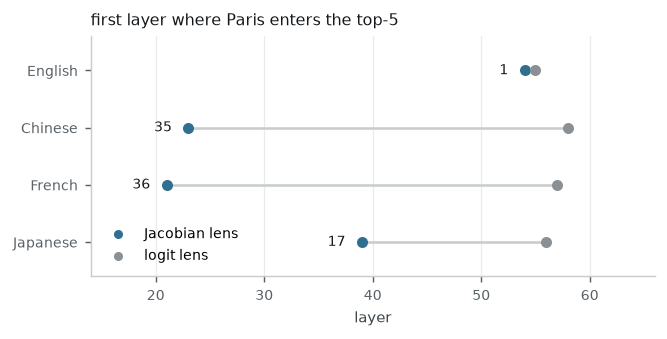

English   'The capital of France is'          jacobian L54   logit L55   1 layers earlier

Chinese   '法国的首都是'                            jacobian L23   logit L58   35 layers earlier

French    'La capitale de la France est'      jacobian L21   logit L57   36 layers earlier

Japanese  'フランスの首都は'                          jacobian L39   logit L56   17 layers earlier

In [18]:
def first_hit(prompt, targets, topk=5):
    ids = encode(prompt)
    residual_by_layer = residuals(ids)
    last_position = ids.shape[1] - 1
    fj = fl = None
    for layer_index in range(layer_count):
        if layer_index not in released_lens:
            continue
        h = residual_by_layer[layer_index][0, last_position]
        j = set(int(t) for t in mx.argsort(-readout(transport(h, layer_index)).astype(mx.float32))[:topk].tolist())
        g = set(int(t) for t in mx.argsort(-readout(h).astype(mx.float32))[:topk].tolist())
        if fj is None and j & targets:
            fj = layer_index
        if fl is None and g & targets:
            fl = layer_index
    return fj, fl


PROMPTS = [("English", "The capital of France is"),
           ("Chinese", "法国的首都是"),
           ("French", "La capitale de la France est"),
           ("Japanese", "フランスの首都は")]

rows = [(lang, p) + first_hit(p, PARIS) for lang, p in PROMPTS]

fig, ax = plt.subplots(figsize=(5.6, 2.4))
for i, (lang, _, fj, fl) in enumerate(rows):
    y = len(rows) - 1 - i
    ax.plot([fj, fl], [y, y], color="#c8cccd", lw=1.4, zorder=1)
    ax.scatter([fj], [y], color=JACOBIAN_COLOR, zorder=2, s=26)
    ax.scatter([fl], [y], color=LOGIT_COLOR, zorder=2, s=26)
    ax.text(min(fj, fl) - 1.5, y, f"{abs(fl - fj)}", color=INK, fontsize=8,
            ha="right", va="center")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([lang for lang, _, _, _ in reversed(rows)])
ax.set_xlim(14, 66)
ax.set_ylim(-0.6, len(rows) - 0.4)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_title("first layer where Paris enters the top-5", loc="left", color=INK)
ax.set_xlabel("layer")
ax.scatter([], [], color=JACOBIAN_COLOR, label="Jacobian lens")
ax.scatter([], [], color=LOGIT_COLOR, label="logit lens")
ax.legend(loc="lower left")
plt.show()

for lang, p, fj, fl in rows:
    print(f"{lang:9s} {p!r:34s}  jacobian L{fj}   logit L{fl}   "
          f"{fl - fj} layers earlier")

### F. J-space 到底是什麼

到這裡讀出的都是「哪個 token 分數最高」,J-space 是比這更強的宣稱。

詞表裡每個 token $t$ 在第 $\ell$ 層的 residual 裡對應一個方向

$$v_t \;=\; \big(W_U J_\ell\big)_t$$

也就是 $W_U J_\ell$ 的第 $t$ 列。讀出時那個 token 的分數就是內積
$\langle v_t, h \rangle$,前面每一次 readout 都是在算所有 token 的這個內積。

J-space 說的是 residual 的一小塊可以寫成少數幾個這種方向的非負組合:

$$h_\ell \;\approx\; \sum_{t \in S} a_t\, v_t, \qquad a_t \ge 0, \qquad |S| \le 25$$

$S$ 是「此刻在 workspace 裡的東西」。非負的理由是這些方向代表「有這個概念」,
負係數沒有對應的意思。

詞表有 248320 個方向,不可能全試,所以先用 readout 分數挑前 $k$ 個候選,再解一個
非負最小平方(投影梯度,步長取 $1/\|G\|_F$ 保證不發散)。$k$ 掃 5、25、100,
另外拿隨機挑的 25 個 token 方向當底線。

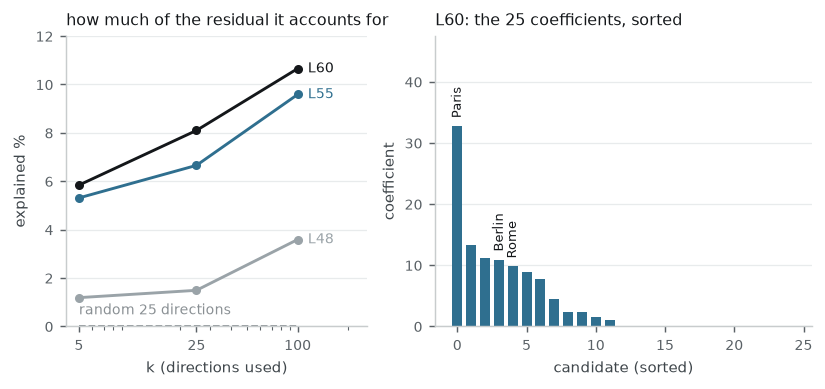

L48  k=5:   1.2%   k=25:   1.5%   k=100:   3.6%   random-25:  0.2%   nonzero 7/25

L55  k=5:   5.3%   k=25:   6.7%   k=100:   9.6%   random-25:  0.1%   nonzero 12/25

L60  k=5:   5.8%   k=25:   8.1%   k=100:  10.7%   random-25:  0.0%   nonzero 12/25

L60 candidates, by readout score: ' Paris' 'Paris' ' London' ' Berlin' ' paris' '巴黎'

L60 largest coefficients:            ' Paris' '\n\n' '____' ' Berlin' ' Rome' ' Madrid'

In [19]:
output_head = language_model.lm_head


def unembed_row(token):
    """One row of W_U, dequantized out of the 4-bit lm_head."""
    i = mx.array([token])
    return mx.dequantize(output_head.weight[i], output_head.scales[i], output_head.biases[i],
                         group_size=output_head.group_size,
                         bits=output_head.bits)[0].astype(mx.float32)


def jlens_vec(token, layer_index):
    """The J-lens direction of one token: row t of W_U @ J_l."""
    return unembed_row(token) @ released_lens[layer_index].astype(mx.float32)


def nnls(V, h, iters=4000):
    """min ||h - V a|| with a >= 0, by projected gradient.

    The step is 1 / ||G||_F, and the Frobenius norm bounds the spectral norm from
    above, so the iteration cannot diverge (a bad step size showed up as negative
    explained variance the first time round).
    """
    G = V.T @ V
    b = V.T @ h
    L = float(mx.sqrt(mx.sum(G * G)))
    a = mx.zeros((V.shape[1],))
    for _ in range(iters):
        a = mx.maximum(a - (G @ a - b) / L, 0.0)
    return a


def jspace_fit(h, layer_index, k=25, tokens=None):
    """Fit h with k J-lens directions: the k best readout scores unless given."""
    if tokens is None:
        scores = readout(transport(h[None, None], layer_index))[0, 0].astype(mx.float32)
        tokens = [int(t) for t in mx.argsort(-scores)[:k].tolist()]
    V = mx.stack([jlens_vec(t, layer_index) for t in tokens], axis=1)
    a = nnls(V, h)
    r = h - V @ a
    return 1.0 - float(mx.sum(r * r) / mx.sum(h * h)), tokens, a


ids = encode("The capital of France is")
residual_by_layer = residuals(ids)
last_position = ids.shape[1] - 1
KS = (5, 25, 100)
LAYERS = (48, 55, 60)
RANDOM_25 = [int(x) for x in mx.random.randint(0, 200000, (25,),
                                               key=mx.random.key(0)).tolist()]

ev, rnd, coef25, tok25 = {}, {}, None, None
for layer_index in LAYERS:
    h = residual_by_layer[layer_index][0, last_position].astype(mx.float32)
    for k in KS:
        e, toks, a = jspace_fit(h, layer_index, k)
        ev[(layer_index, k)] = e
        if k == 25 and layer_index == 60:
            coef25, tok25 = a, toks
        if k == 25:
            ev[(layer_index, "nz")] = int(mx.sum(a > 1e-6))
    rnd[layer_index] = jspace_fit(h, layer_index, tokens=RANDOM_25)[0]

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.9),
                         gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
for layer_index, c in zip(LAYERS, (MUTED_COLOR, JACOBIAN_COLOR, INK)):
    ax.plot(KS, [ev[(layer_index, k)] * 100 for k in KS], marker="o", color=c)
    ax.text(KS[-1] * 1.15, ev[(layer_index, KS[-1])] * 100, f"L{layer_index}", color=c, fontsize=8,
            va="center")
ax.plot(KS, [rnd[LAYERS[-1]] * 100] * len(KS), color=LOGIT_COLOR, ls="--", lw=1.0)
ax.text(KS[0], rnd[LAYERS[-1]] * 100 + 0.35, "random 25 directions", color=LOGIT_COLOR,
        fontsize=7.5, va="bottom")
ax.set_xscale("log")
ax.set_xticks(KS)
ax.set_xticklabels([str(k) for k in KS])
ax.set_xlim(4.2, 260)
panel(ax, "how much of the residual it accounts for", "k (directions used)",
      "explained %", 12)

ax = axes[1]
order = mx.argsort(-coef25).tolist()
vals = [float(coef25[i]) for i in order]
ax.bar(range(25), vals, color=[JACOBIAN_COLOR if v > 1e-6 else "#dfe3e4" for v in vals],
       width=0.72)
shown = 0
for i in range(25):
    tk = tokenizer.decode([tok25[order[i]]]).strip()
    if shown >= 3 or not tk.isalpha():
        continue
    ax.text(i, vals[i] + max(vals) * 0.04, tk, rotation=90, fontsize=7,
            color=INK, ha="center", va="bottom")
    shown += 1
ax.set_ylim(0, max(vals) * 1.45)
panel(ax, "L60: the 25 coefficients, sorted", "candidate (sorted)",
      "coefficient", None)
plt.show()

for layer_index in LAYERS:
    print(f"L{layer_index}  " + "   ".join(f"k={k}: {ev[(layer_index, k)] * 100:5.1f}%" for k in KS)
          + f"   random-25: {rnd[layer_index] * 100:4.1f}%   nonzero {ev[(layer_index, 'nz')]}/25")
print("L60 candidates, by readout score: "
      + " ".join(repr(tokenizer.decode([t])) for t in tok25[:6]))
print("L60 largest coefficients:            "
      + " ".join(repr(tokenizer.decode([tok25[i]])) for i in order[:6]))

### G. 換掉 J-space 裡的概念

對齊[原文的實驗](https://www.anthropic.com/research/global-workspace):四個 prompt
分別問 France 的首都、語言、所屬洲、貨幣,在 J-space 裡把 `France` 換成 `China`,
四個情境用完全相同的介入。四個答案一起改的話,最簡單的解釋是它們讀的是同一份表徵。

做法是論文的 lens coordinate patching,用的就是 附錄 F 那些 $v_t$:

$$V = [\,v_s \;\; v_t\,], \qquad c = V^{\dagger} h, \qquad
h \leftarrow h + \alpha\, V\,(\sigma(c) - c)$$

$c$ 是 $h$ 在這兩個方向上的座標,$\sigma$ 把兩個座標交換,跟
$\mathrm{span}\{v_s, v_t\}$ 正交的成分不動。幾何上只動了這個平面;語義上是不是
只換掉 France 這一個概念,公式不保證,要看輸出。

$V^{\dagger}$ 是 pseudo-inverse。不能直接拿內積當座標,因為 J-lens 向量 overcomplete
而且彼此不正交,下面會看到 $v_{\text{France}}$ 跟 $v_{\text{China}}$ 的 cosine 有 0.44,
直接取內積會把重疊的部分算兩次。

In [20]:
def coords(x, vs, vt):
    V = mx.stack([vs, vt], axis=1)
    return V, mx.linalg.pinv(V, stream=mx.cpu) @ x


def swap(x, vs, vt, alpha):
    V, c = coords(x, vs, vt)
    return x + alpha * (V @ (c[::-1] - c))


def add_only(x, vs, vt, alpha):
    V, c = coords(x, vs, vt)
    return x + alpha * (c[0] - c[1]) * vt


FRANCE, CHINA = tokenizer.encode(" France")[0], tokenizer.encode(" China")[0]
vf, vc = jlens_vec(FRANCE, 48), jlens_vec(CHINA, 48)
cos = float(vf @ vc / (mx.linalg.norm(vf) * mx.linalg.norm(vc)))
print(f"v_France at L48: {tuple(vf.shape)}, norm {float(mx.linalg.norm(vf)):.1f}")
print(f"cos(v_France, v_China) = {cos:+.3f}")

v_France at L48: (5120,), norm 1.4

cos(v_France, v_China) = +0.441

三個選擇決定成不成:

- 層:L40 到 L55。層數是掃出來的,更早的層改了幾乎沒反應,更晚的層改了會把概念直接
  說出來(附錄 H.5 有數字)。
- 位置:只改 `France` 那個 token,不碰最後一個位置。最後幾層的 J-lens 方向是「準備要
  說出口的字」,在那裡動手 model 會輸出 `China` 而不是拿它去推理。
- 強度:$\alpha = 1$ 是嚴格的交換,$\alpha = 2$ 是推過頭的版本,兩個都跑。

對照組 `add_only` 只加上 `China` 的成分,不把 `France` 拿掉。

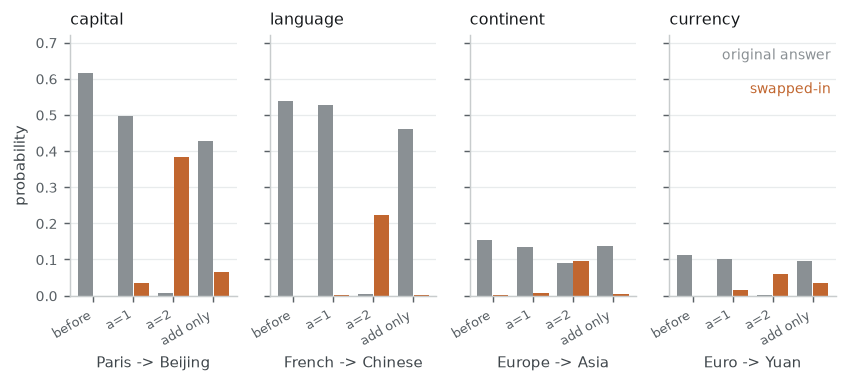

'The capital of France is'

before        ' Paris'    p( Paris)=0.617  p( Beijing)=0.000

swap a=1      ' Paris'    p( Paris)=0.497  p( Beijing)=0.034

swap a=2      ' Beijing'  p( Paris)=0.006  p( Beijing)=0.383

add only a=2  ' Paris'    p( Paris)=0.427  p( Beijing)=0.066

...

'The currency of France is called the'

before        ' euro'     p( Euro)=0.111  p( Yuan)=0.000

swap a=1      ' euro'     p( Euro)=0.101  p( Yuan)=0.017

swap a=2      ' yuan'     p( Euro)=0.001  p( Yuan)=0.060

add only a=2  ' euro'     p( Euro)=0.097  p( Yuan)=0.036

In [21]:
BAND = [layer_index for layer_index in released_lens if 40 <= layer_index < 56]
ALPHA = 2.0


def patched(ids, pos, alpha, edit=swap):
    h = decoder.embed_tokens(ids)
    fa, ssm, p = prepare_layer_inputs(h)
    for layer_index, layer in enumerate(decoder.layers):
        h = layer(h, mask=(ssm if layer.is_linear else fa),
                  cache=None, position_ids=p, position_embeddings=None)
        if alpha and layer_index in BAND:
            h[0, pos] = edit(h[0, pos].astype(mx.float32),
                             jlens_vec(FRANCE, layer_index), jlens_vec(CHINA, layer_index),
                             alpha).astype(model_dtype)
    return readout(h)[0, ids.shape[1] - 1].astype(mx.float32)


def p_of(scores, s):
    return float(mx.softmax(scores)[tokenizer.encode(s)[0]])


def top1(scores):
    return tokenizer.decode([int(mx.argmax(scores))])


TASKS = [("capital", "The capital of France is", " Paris", " Beijing"),
         ("language", "The language spoken in France is", " French", " Chinese"),
         ("continent", "The continent that contains France is", " Europe", " Asia"),
         ("currency", "The currency of France is called the", " Euro", " Yuan")]
CONDS = ["before", "swap a=1", "swap a=2", "add only a=2"]

table = {}
for name, prompt, orig, new in TASKS:
    ids = encode(prompt)
    toks = [tokenizer.decode([int(t)]) for t in ids[0].tolist()]
    pos = next(i for i, t in enumerate(toks) if "France" in t)
    for cond, scores in zip(CONDS, [patched(ids, pos, 0),
                                patched(ids, pos, 1.0),
                                patched(ids, pos, ALPHA),
                                patched(ids, pos, ALPHA, add_only)]):
        table[(name, cond)] = (p_of(scores, orig), p_of(scores, new), top1(scores))

fig, axes = plt.subplots(1, 4, figsize=(7.6, 2.6), sharey=True)
x = mx.arange(len(CONDS)).tolist()
for ax, (name, _, orig, new) in zip(axes, TASKS):
    o = [table[(name, c)][0] for c in CONDS]
    n = [table[(name, c)][1] for c in CONDS]
    ax.bar([i - 0.2 for i in x], o, width=0.38, color=LOGIT_COLOR)
    ax.bar([i + 0.2 for i in x], n, width=0.38, color=ACCENT_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(["before", "a=1", "a=2", "add only"],
                       fontsize=7, rotation=30, ha="right")
    panel(ax, name, f"{orig.strip()} -> {new.strip()}", "", 0.72)
axes[0].set_ylabel("probability")
axes[3].text(0.97, 0.95, "original answer", color=LOGIT_COLOR, fontsize=8,
             transform=axes[3].transAxes, va="top", ha="right")
axes[3].text(0.97, 0.82, "swapped-in", color=ACCENT_COLOR, fontsize=8,
             transform=axes[3].transAxes, va="top", ha="right")
plt.show()

for name, prompt, orig, new in TASKS:
    print(f"{prompt!r}")
    for c in CONDS:
        po, pn, t = table[(name, c)]
        print(f"   {c:13s} {t!r:11s} p({orig})={po:.3f}  p({new})={pn:.3f}")

### H. 論文的五個 workspace 面向

論文給了五個功能面向,要一項一項成立才算 workspace
([原文圖 2](https://www.anthropic.com/research/global-workspace)):

| 面向 | 問題 |
| --- | --- |
| verbal report | 問它在想什麼,它說得出來嗎 |
| directed modulation | 叫它想 X、或叫它不要想 X,J-space 跟著動嗎 |
| internal reasoning | 它會拿 J-space 裡的東西去推理,還是只是存著 |
| flexible generalization | 同一個概念,換到不同任務還通嗎 |
| selectivity | 只有進 workspace 的內容才影響行為嗎 |

flexible generalization 就是 附錄 G 做的事,一個介入、四個任務一起改。這一節跑剩下四個,
另外加一個論文用來驗因果的手法:把概念消除。

介入先寫成一個通用的 forward,`edits` 是一串 `(position, 函式)`,每一層都套上去。

In [22]:
SCAN = [layer_index for layer_index in released_lens if 40 <= layer_index < 62 and layer_index % 2 == 0]


def tid(word):
    """First token id of a spelling."""
    return tokenizer.encode(word)[0]


def edited(ids, edits=(), layers=BAND):
    """Forward pass with edits = [(position, fn)] applied at every layer in `layers`."""
    h = decoder.embed_tokens(ids)
    fa, ssm, p = prepare_layer_inputs(h)
    for layer_index, layer in enumerate(decoder.layers):
        h = layer(h, mask=(ssm if layer.is_linear else fa),
                  cache=None, position_ids=p, position_embeddings=None)
        if layer_index in layers:
            for pos, fn in edits:
                h[0, pos] = fn(h[0, pos].astype(mx.float32), layer_index).astype(model_dtype)
    return readout(h)[0, ids.shape[1] - 1].astype(mx.float32)


def best_readout(ids, words, layers=SCAN):
    """Largest J-lens probability of any spelling, over every layer and position."""
    residual_by_layer = residuals(ids)
    best = (0.0, None, None)
    for layer_index in layers:
        sm = mx.softmax(readout(transport(residual_by_layer[layer_index], layer_index)).astype(mx.float32), axis=-1)[0]
        for w in words:
            col = sm[:, tid(w)]
            p = float(mx.max(col))
            if p > best[0]:
                best = (p, layer_index, int(mx.argmax(col)))
    return best


def probs(scores, *pairs):
    sm = mx.softmax(scores)
    return "  ".join(f"p({n})={max(float(sm[tid(w)]) for w in ws):.3f}"
                     for n, ws in pairs)


def where(ids, word):
    toks = [tokenizer.decode([int(t)]) for t in ids[0].tolist()]
    return next(i for i, t in enumerate(toks) if word in t)


print(f"scan layers: {SCAN[0]}..{SCAN[-1]} ({len(SCAN)})   patch band: "
      f"L{BAND[0]}-{BAND[-1]}")

scan layers: 40..60 (11)   patch band: L40-55

#### H.1 定向調節:叫它想,叫它不要想

同一句抄寫任務,後面接不同的指令,量 J-space 裡有沒有那個概念。兩組設計:

- 白熊。`bear` 在兩個 prompt 裡都出現,「因為輸入有這個字才讀到」的效應互相抵銷,
  差的只有指令。
- lemon。指令說的是 citrus fruit,`lemon` 從頭到尾沒出現在 prompt 裡,讀到它就不能
  用 input-copying 解釋。對照組把指令換成想呼吸,測「任何指令都會抬高一切」。

讀法是掃 L40 到 L60 每一層、每一個位置,取最大的機率。

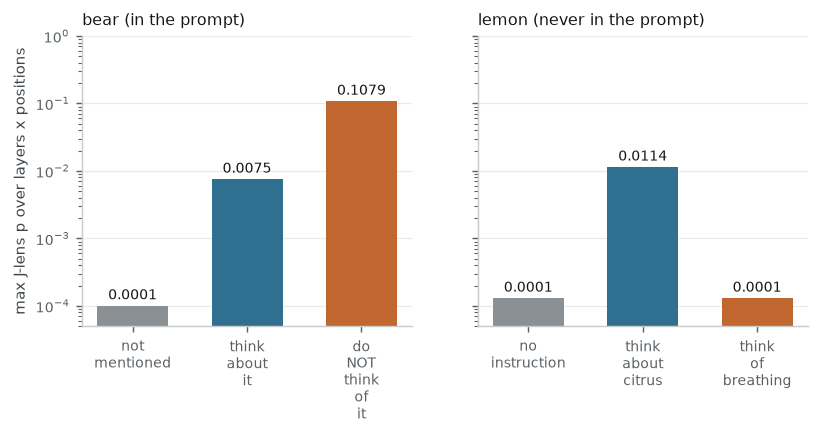

bear (in the prompt)         not mentioned        max p = 0.0001   at L60 pos5

bear (in the prompt)         think about it       max p = 0.0075   at L54 pos23

bear (in the prompt)         do NOT think of it   max p = 0.1079   at L60 pos24

lemon (never in the prompt)  no instruction       max p = 0.0001   at L48 pos3

lemon (never in the prompt)  think about citrus   max p = 0.0114   at L58 pos22

lemon (never in the prompt)  think of breathing   max p = 0.0001   at L48 pos3

In [23]:
S = 'Write the sentence "The old painting hung crookedly on the wall."'

CASES = [
    ("bear (in the prompt)", (" bear", " bears"), [
        ("not mentioned", S),
        ("think about it", S + " While you write, think about a white bear."),
        ("do NOT think of it", S + " While you write, do not think about a white bear.")]),
    ("lemon (never in the prompt)", (" lemon", " lemons"), [
        ("no instruction", S),
        ("think about citrus", S + " While you write, think about citrus fruit."),
        ("think of breathing", S + " While you write, think about your breathing.")]),
]

got = []
for target, words, cases in CASES:
    for tag, prompt in cases:
        p, layer_index, pos = best_readout(encode(prompt), words)
        got.append((target, tag, p, layer_index, pos))

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), sharey=True)
for ax, (target, words, cases) in zip(axes, CASES):
    rows = [g for g in got if g[0] == target]
    vals = [g[2] for g in rows]
    ax.bar(range(len(rows)), vals,
           color=[LOGIT_COLOR, JACOBIAN_COLOR, ACCENT_COLOR][:len(rows)], width=0.62)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.25, f"{v:.4f}", ha="center", fontsize=7.5, color=INK)
    ax.set_xticks(range(len(rows)))
    ax.set_xticklabels([g[1].replace(" ", "\n") for g in rows], fontsize=7.5)
    ax.set_yscale("log")
    ax.set_ylim(5e-5, 1.0)
    panel(ax, target, "", "", None)
axes[0].set_ylabel("max J-lens p over layers x positions")
plt.show()

for target, tag, p, layer_index, pos in got:
    print(f"{target:28s} {tag:20s} max p = {p:.4f}   at L{layer_index} pos{pos}")

白熊那組成立,而且方向是反的。沒提到白熊時 J-space 裡幾乎沒有它,
max p = 0.0001;叫它想白熊升到 0.0075;叫它不要想白熊升到 0.1079,比叫它想的時候
高一個數量級以上。抑制的指令沒有把概念壓下去,反而把它推進 workspace,
論文圖 10 有跨 model 的版本。

lemon 那組是乾淨的正向。指令說的是 citrus fruit,`lemon` 從沒出現在 prompt 裡,
J-space 讀到 0.0114;把指令換成想呼吸掉回 0.0001,跟完全沒有指令一樣。
動的是被指定的那個概念,不是有指令就整體抬高。

絕對值都很小,0.0001 到 0.1,要看的是同一個 target 在不同指令之間的比值。

#### H.2 把概念消除

交換是把座標換過去,消除是把座標歸零,同一套機制取 $\sigma(c) = 0$:

$$V = [\,v_1 \cdots v_k\,], \qquad h \leftarrow h - \alpha\, V\,(V^{\dagger} h)$$

一次投掉整組方向。J-lens 向量彼此不正交,一個一個減會重複扣掉共用的成分。

介入從最小的開始加碼:一個方向、一個位置,到一個方向、所有位置,再到整組
`{France, French, Paris}`、所有位置。另外也試直接把答案方向 `Paris` 拿掉。

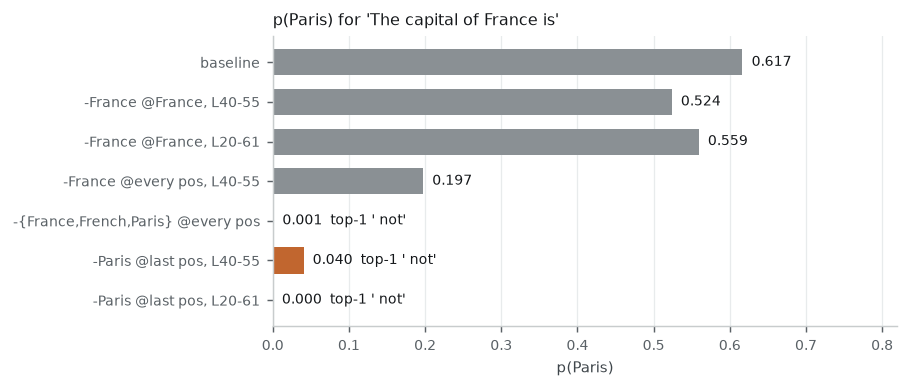

baseline                           p(Paris)=0.617   top1=' Paris'

-France @France, L40-55            p(Paris)=0.524   top1=' Paris'

-France @France, L20-61            p(Paris)=0.559   top1=' Paris'

-France @every pos, L40-55         p(Paris)=0.197   top1=' Paris'

-{France,French,Paris} @every pos  p(Paris)=0.001   top1=' not'

-Paris @last pos, L40-55           p(Paris)=0.040   top1=' not'

-Paris @last pos, L20-61           p(Paris)=0.000   top1=' not'

In [24]:
def ablate_span(words, alpha=1.0):
    """h <- h - alpha * V (V+ h): project out the span of several J-lens directions."""
    def f(x, layer_index):
        V = mx.stack([jlens_vec(tid(w), layer_index) for w in words], axis=1)
        return x - alpha * (V @ (mx.linalg.pinv(V, stream=mx.cpu) @ x))
    return f


PROMPT = "The capital of France is"
ids = encode(PROMPT)
france_position, last_position = where(ids, "France"), ids.shape[1] - 1
WIDE = [layer_index for layer_index in released_lens if 20 <= layer_index < 62]
ALL = list(range(ids.shape[1]))

RUNS = [
    ("baseline", (), BAND),
    ("-France @France, L40-55", ((france_position, ablate_span([" France"])),), BAND),
    ("-France @France, L20-61", ((france_position, ablate_span([" France"])),), WIDE),
    ("-France @every pos, L40-55", tuple((p, ablate_span([" France"])) for p in ALL), BAND),
    ("-{France,French,Paris} @every pos", tuple((p, ablate_span([" France", " French", " Paris"])) for p in ALL), BAND),
    ("-Paris @last pos, L40-55", ((last_position, ablate_span([" Paris"])),), BAND),
    ("-Paris @last pos, L20-61", ((last_position, ablate_span([" Paris"])),), WIDE),
]

out = []
for tag, edits, layers in RUNS:
    scores = edited(ids, edits, layers)
    out.append((tag, float(mx.softmax(scores)[tid(" Paris")]), top1(scores)))

fig, ax = plt.subplots(figsize=(6.2, 2.9))
y = list(range(len(out)))[::-1]
vals = [o[1] for o in out]
ax.barh(y, vals, color=[LOGIT_COLOR if o[2] == " Paris" else ACCENT_COLOR for o in out],
        height=0.66)
for yi, (tag, v, t) in zip(y, out):
    ax.text(v + 0.012, yi, f"{v:.3f}" + ("" if t == " Paris" else f"  top-1 {t!r}"),
            va="center", fontsize=7.5, color=INK)
ax.set_yticks(y)
ax.set_yticklabels([o[0] for o in out], fontsize=7.5)
ax.set_xlim(0, 0.82)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_title(f"p(Paris) for {PROMPT!r}", loc="left", color=INK)
ax.set_xlabel("p(Paris)")
plt.show()

for tag, v, t in out:
    print(f"{tag:34s} p(Paris)={v:.3f}   top1={t!r}")

消除成不成看你動多少。

- 投掉 `France` 一個方向,只在 `France` 那個位置:`p(Paris)` 從 0.617 到 0.524。
- 同一個方向,層數放寬到 L20-61:0.559。
- 一個方向,每個位置都投:0.197,掉了三分之二。
- 整組 `{France, French, Paris}`、每個位置:0.001,top-1 變成 `' not'`。
- 直接投掉答案方向 `Paris`,只在最後一個位置:0.040;層數放寬到 L20-61 是 0.000。

概念不是只存在提到它的那個位置上,`France` 的資訊在 forward 的過程中已經散到別的位置,
只掐一個點沒用。要投也得投整組,一個一個減會漏掉共用的成分。

#### H.3 選擇性:明確報告 vs 自動處理

論文說進了 workspace 的內容只在需要報告或彈性使用時起作用,自動處理那條路走不到它,
[原文圖 8](https://www.anthropic.com/research/global-workspace) 的例子是一段西班牙文。

兩個 prompt 共用同一句西班牙文,介入完全相同,把西班牙文那幾個 token 的 `Spanish`
座標換成 `French`:

- 明確報告:問這句是什麼語言。翻得動代表這個概念被拿去回答問題。
- 自動處理:叫它照原樣接下去。論文的說法成立的話,這條不該受影響,照樣接西班牙文。

強度要掃過去,不能挑一個 $\alpha$ 交差。

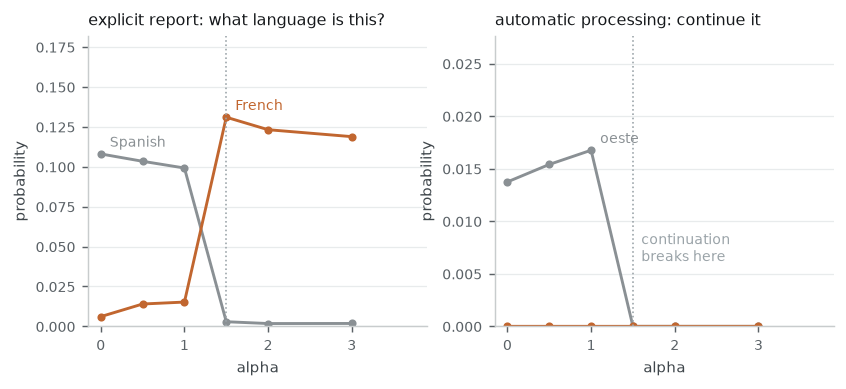

'Sentence: "El sol se pone en el oeste." That sentence is written in'   patched positions 3..9

alpha=0    p(Spanish)=0.108  p(French)=0.006   top1=' which'

alpha=0.5  p(Spanish)=0.103  p(French)=0.014   top1=' which'

alpha=1.0  p(Spanish)=0.099  p(French)=0.015   top1=' which'

alpha=1.5  p(Spanish)=0.003  p(French)=0.131   top1=' which'

...

alpha=0.5  p(oeste)=0.015  p(ouest)=0.000   top1=' horizonte'

alpha=1.0  p(oeste)=0.017  p(ouest)=0.000   top1=' horizonte'

alpha=1.5  p(oeste)=0.000  p(ouest)=0.000   top1=' Spanish'

alpha=2.0  p(oeste)=0.000  p(ouest)=0.000   top1=' Spanish'

alpha=3.0  p(oeste)=0.000  p(ouest)=0.000   top1=' Spanish'

In [25]:
def swap_lang(alpha, src=" Spanish", tgt=" French"):
    return lambda x, layer_index: swap(x, jlens_vec(tid(src), layer_index), jlens_vec(tid(tgt), layer_index), alpha)


EXPLICIT = 'Sentence: "El sol se pone en el oeste." That sentence is written in'
AUTO = 'Continue in the same language: "El sol se pone en el'
ALPHAS = (0, 0.5, 1.0, 1.5, 2.0, 3.0)

runs = []
for prompt, keys, lastw in [
        (EXPLICIT, (("Spanish", " Spanish"), ("French", " French")), " oeste"),
        (AUTO, (("oeste", " oeste"), ("ouest", " ouest")), " el")]:
    ids = encode(prompt)
    toks = [tokenizer.decode([int(t)]) for t in ids[0].tolist()]
    a = where(ids, "El")
    b = max(i for i, t in enumerate(toks) if t == lastw)
    ps = list(range(a, b + 1))
    series = {name: [] for name, _ in keys}
    tops = []
    for alpha in ALPHAS:
        edits = () if alpha == 0 else tuple((p, swap_lang(alpha)) for p in ps)
        scores = edited(ids, edits)
        for name, w in keys:
            series[name].append(float(mx.softmax(scores)[tid(w)]))
        tops.append(top1(scores))
    runs.append((prompt, ps, series, tops))

fig, axes = plt.subplots(1, 2, figsize=(7.4, 2.9))
TITLES = ["explicit report: what language is this?",
          "automatic processing: continue it"]
for ax, (prompt, ps, series, tops), title in zip(axes, runs, TITLES):
    for (name, vals), c in zip(series.items(), (LOGIT_COLOR, ACCENT_COLOR)):
        ax.plot(ALPHAS, vals, marker="o", ms=3.5, color=c)
        if max(vals) > 0.002:
            j = vals.index(max(vals))
            ax.annotate(name, (ALPHAS[j], vals[j]), textcoords="offset points",
                        xytext=(5, 4), color=c, fontsize=8)
    ax.axvline(1.5, color=MUTED_COLOR, lw=0.9, ls=":")
    ax.set_xlim(-0.15, 3.9)
    top = max(max(v) for v in series.values())
    panel(ax, title, "alpha", "", top * 1.35 + 0.005)
axes[0].set_ylabel("probability")
axes[1].set_ylabel("probability")
axes[1].text(1.6, 0.009, "continuation\nbreaks here", color=MUTED_COLOR, fontsize=7.5,
             va="top")
plt.show()

for prompt, ps, series, tops in runs:
    print(f"{prompt!r}   patched positions {ps[0]}..{ps[-1]}")
    for i, alpha in enumerate(ALPHAS):
        cols = "  ".join(f"p({n})={v[i]:.3f}" for n, v in series.items())
        print(f"   alpha={alpha:<4} {cols}   top1={tops[i]!r}")

只成立一半。

明確報告那條翻得動,但要 $\alpha = 1.5$。$\alpha \le 1.0$ 時 `p(Spanish)` 還是 0.099、
`p(French)` 0.015,到 $\alpha = 1.5$ 時 `p(Spanish)` 掉到 0.003,`p(French)` 升到 0.131。

自動接續那條在 $\alpha \le 1.0$ 完全不受影響,照樣接 `' horizonte'`,`p(oeste)` 甚至
微升。到 $\alpha = 1.5$ 就壞了,而且不是變成法文,top-1 變成 `' Spanish'`,
它開始講語言的名字而不是接句子。

兩條路的門檻是同一個,能讓明確報告翻過去的強度剛好也是讓自動接續脫軌的強度,
所以拿不到論文那個乾淨的分離。能說的只有:在自動接續還正常的強度下,概念的改動
沒有影響它。

#### H.4 口頭報告:注入一個概念,問它在想什麼

把一個概念寫進 residual stream,再問它腦裡有什麼,論文的結果是它會說出那個字。

「它說出那個字」有兩種解釋:它讀到了自己 workspace 裡的內容再報告出來,或者注入直接
偏移了輸出分布,不管問什麼都會說。所以要有對照組,同一個注入換一個完全無關的問題,
如果那邊也照樣說出來就不能算報告。

In [26]:
ASK = "What single word is on your mind right now? Answer with one word:"
CONTROL = "The capital of France is"


def inject(word, alpha):
    def f(x, layer_index):
        v = jlens_vec(tid(word), layer_index)
        return x + alpha * v / mx.linalg.norm(v) * mx.linalg.norm(x)
    return f


def generate(ids, n=5, edits=(), layers=BAND):
    """Greedy continuation, re-running the whole forward for each token."""
    cur, out = ids, []
    for _ in range(n):
        t = int(mx.argmax(edited(cur, edits, layers)))
        if t in tokenizer.all_special_ids:
            break
        out.append(t)
        cur = mx.concatenate([cur, mx.array([[t]])], axis=1)
    return tokenizer.decode(out)


for word, alpha in ((" volcano", 0.0), (" volcano", 0.5), (" volcano", 1.0),
                    (" guitar", 0.5)):
    line = []
    for prompt, n in ((ASK, 5), (CONTROL, 4)):
        ids = encode(prompt)
        edits = () if alpha == 0 else tuple((p, inject(word, alpha))
                                            for p in range(ids.shape[1]))
        line.append(generate(ids, n, edits))
    print(f"inject{word:9s} alpha={alpha:<4}  ask -> {line[0]!r:26s}"
          f"  control -> {line[1]!r}")

inject volcano  alpha=0.0   ask -> "\n\n<think>\nHere's"       control -> ' Paris.\n\n<think>'

inject volcano  alpha=0.5   ask -> ' volcano.\n\n<think>\n'    control -> ' volcano.\n\n<think>'

inject volcano  alpha=1.0   ask -> ' volcano.\n\n<think>\n'    control -> ' volcano, and the'

inject guitar   alpha=0.5   ask -> ' guitar.\n\n<think>\n'     control -> ' guitar.\n\n<think>'

不成立,對照組把它打掉了。

注入之後它確實會說。問「你現在想到哪一個字」,$\alpha = 0.5$ 答 `' volcano.'`,
換成 guitar 答 `' guitar.'`,沒注入的時候它只會進 `<think>`。

但對照組也照樣說。同一個注入問 `The capital of France is`,答的是 volcano 或 guitar
而不是 Paris,$\alpha$ 從 0.5 到 1.0 都一樣。

在這顆 model 上,這個注入只是把輸出分布推向那個字,不能算報告 workspace 的內容。
要分開這兩件事,得找到一個強度或位置讓「問它想什麼」會說出來、「問別的問題」不會,
我掃過的範圍裡沒有。

#### H.5 內部推理:交換之後,它會拿新概念去算嗎

這一項要求交換之後 model 用新概念做推論,而不是把它輸出。兩種題型。

數腳,論文圖 6 的例子:把 spider 換成 ant,問腳的數量,答案該從 8 變 6。`8` 和 `6`
都不在 prompt 裡,也不是被交換的那兩個字。這顆 model 是 thinking model,問句形式會讓
它先吐 `\n\n`,所以用完成句的寫法。

兩跳事實:`The capital of the country where the Eiffel Tower stands is` 答 Paris,
中間那一跳 France 完全不在 prompt 裡,是 model 自己算出來的。把 France 換成 China 之後,
答 Beijing 代表它拿新概念又跑了一次第二跳,答 China 代表它只是把注入的東西講出來。
這個題型能把推理和洩漏分開。

第二種還要挑位置。France 不在輸入裡,沒有「France 那個 token 的位置」可以改,
只能改別的位置,三個選擇都試:最後一個位置、`Tower` 那個位置、除了最後一個以外全改。

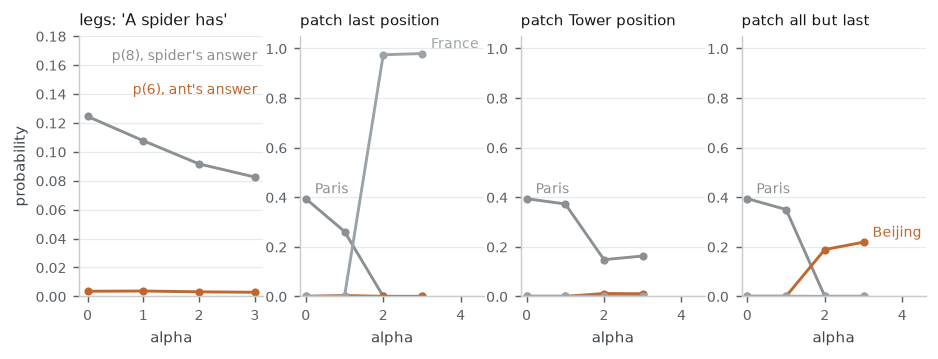

'A spider has'   swap spider -> ant

alpha=0    p(8)=0.124  p(6)=0.004   top1=' '

alpha=1.0  p(8)=0.108  p(6)=0.004   top1=' '

alpha=2.0  p(8)=0.092  p(6)=0.003   top1=' '

alpha=3.0  p(8)=0.083  p(6)=0.003   top1=' '

...

patch all but last  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

alpha=0    p(Paris)=0.394  p(Beijing)=0.000  p(France)=0.001   top1=' Paris'

alpha=1.0  p(Paris)=0.350  p(Beijing)=0.000  p(France)=0.001   top1=' Paris'

alpha=2.0  p(Paris)=0.000  p(Beijing)=0.189  p(France)=0.000   top1=' Beijing'

alpha=3.0  p(Paris)=0.000  p(Beijing)=0.218  p(France)=0.000   top1=' Beijing'

In [27]:
EIGHT, SIX = ("8", " eight"), ("6", " six")
ALPHAS = (0, 1.0, 2.0, 3.0)

legs = {}
for prompt, src, tgt, keep, want in [
        ("A spider has", " spider", " ant", EIGHT, SIX),
        ("The number of legs on a spider is", " spider", " ant", EIGHT, SIX)]:
    ids = encode(prompt)
    pos = where(ids, src.strip())
    for alpha in ALPHAS:
        edits = () if alpha == 0 else (
            (pos, lambda x, layer_index, a=alpha: swap(x, jlens_vec(tid(src), layer_index),
                                             jlens_vec(tid(tgt), layer_index), a)),)
        scores = edited(ids, edits)
        sm = mx.softmax(scores)
        legs[(prompt, alpha)] = (max(float(sm[tid(w)]) for w in keep),
                                 max(float(sm[tid(w)]) for w in want),
                                 top1(scores))

TWO_HOP = "The capital of the country where the Eiffel Tower stands is"
ids = encode(TWO_HOP)
last_position = ids.shape[1] - 1
TARGETS = [("last position", [last_position]),
           ("Tower position", [where(ids, "Tower")]),
           ("all but last", list(range(1, last_position)))]
WATCH = [("Paris", " Paris"), ("Beijing", " Beijing"), ("France", " France")]


def swap_fc(alpha):
    return lambda x, layer_index: swap(x, jlens_vec(tid(" France"), layer_index),
                             jlens_vec(tid(" China"), layer_index), alpha)


hop = {}
for tag, ps in TARGETS:
    for alpha in ALPHAS:
        edits = () if alpha == 0 else tuple((p, swap_fc(alpha)) for p in ps)
        scores = edited(ids, edits)
        sm = mx.softmax(scores)
        hop[(tag, alpha)] = ({n: float(sm[tid(w)]) for n, w in WATCH}, top1(scores))

fig, axes = plt.subplots(1, 4, figsize=(8.4, 2.6))

ax = axes[0]
p = "A spider has"
ax.plot(ALPHAS, [legs[(p, a)][0] for a in ALPHAS], marker="o", ms=3.5, color=LOGIT_COLOR)
ax.plot(ALPHAS, [legs[(p, a)][1] for a in ALPHAS], marker="o", ms=3.5, color=ACCENT_COLOR)
ax.text(0.97, 0.95, "p(8), spider's answer", color=LOGIT_COLOR, fontsize=7.5,
        transform=ax.transAxes, va="top", ha="right")
ax.text(0.97, 0.82, "p(6), ant's answer", color=ACCENT_COLOR, fontsize=7.5,
        transform=ax.transAxes, va="top", ha="right")
panel(ax, "legs: 'A spider has'", "alpha", "probability", 0.18)
axes[1].set_ylabel("probability")

for ax, (tag, _) in zip(axes[1:], TARGETS):
    for (name, _), c in zip(WATCH, (LOGIT_COLOR, ACCENT_COLOR, MUTED_COLOR)):
        ys = [hop[(tag, a)][0][name] for a in ALPHAS]
        ax.plot(ALPHAS, ys, marker="o", ms=3.5, color=c)
        if max(ys) > 0.05:
            j = ys.index(max(ys))
            ax.annotate(name, (ALPHAS[j], ys[j]), textcoords="offset points",
                        xytext=(5, 3), color=c, fontsize=7.5)
    ax.set_xlim(-0.15, 4.6)
    panel(ax, f"patch {tag}", "alpha", "", 1.05)
    ax.set_title(f"patch {tag}", loc="left", color=INK, fontsize=8.5)
plt.show()

for prompt in ("A spider has", "The number of legs on a spider is"):
    print(f"{prompt!r}   swap spider -> ant")
    for a in ALPHAS:
        k, w, t = legs[(prompt, a)]
        print(f"   alpha={a:<4} p(8)={k:.3f}  p(6)={w:.3f}   top1={t!r}")
print(f"\ntwo-hop: {TWO_HOP!r}")
print(f"  'France' appears in the prompt: {'France' in TWO_HOP}")
for tag, ps in TARGETS:
    print(f"  patch {tag}  {ps}")
    for a in ALPHAS:
        d, t = hop[(tag, a)]
        cols = "  ".join(f"p({n})={d[n]:.3f}" for n, _ in WATCH)
        print(f"    alpha={a:<4} {cols}   top1={t!r}")

數腳那組不成立,`p(8)` 從 0.124 掉到 0.083,`p(6)` 從 0.004 完全沒動。
交換把舊概念弄壞了,沒把新概念的後果裝上去。

兩跳事實那組成立,但位置決定一切:

- 只改最後一個位置:$\alpha = 2$ 時 `p(France)` 衝到 0.975,top-1 是 `' France'`。
  它把被交換的概念直接說出來,這就是前面提的 late-layer 洩漏,現在有數字。
- 只改 `Tower` 那個位置:幾乎沒反應,`p(Beijing)` 最多 0.011,單一個位置扛不起來。
- 除了最後一個以外全改:$\alpha = 2$ 時 top-1 變成 `' Beijing'`,`p(Paris)` 掉到 0.000,
  而 `p(France)`、`p(China)` 都還在 0.000 到 0.001。

最後那個是要找的結果。它沒有把 `China` 講出來,講的是第二跳的結果,而被換掉的概念
從頭到尾不在輸入裡,所以也不可能是 input-copying。

兩個題型合起來,結論跟 Neel Nanda 團隊的複現一致:多跳事實的替換站得住,需要算的
那種不行。數腳要的是「知道 ant 有 6 隻腳」這種屬性查詢,兩跳事實要的是「拿 China
再跑一次首都查詢」,後者這顆 model 做得到。

### I. 跑完的樣子

| 面向 | 這顆 model(Qwen3.6-27B-4bit) |
| --- | --- |
| flexible generalization | 成立。一個介入,四個任務一起改(附錄 G) |
| directed modulation | 成立,但抑制無效。叫它不要想白熊,白熊反而更清楚 |
| internal reasoning | 成立,但只有兩跳事實那種,數腳那種不行 |
| 概念消除(論文驗因果的手法) | 成立,但要投整組方向、每個位置都投 |
| selectivity | 一半。明確報告翻得動,但拿不到跟自動處理的乾淨分離 |
| verbal report | 不成立。注入之後,問什麼都會說出那個字 |

四項成立、一項一半、一項不成立。這是一顆 27B 的 4-bit 量化 model,不是 Sonnet 4.5,
效應本來就該弱得多。

成立的那幾項有一個共同的條件:介入要落在內容位置,而且往往要落在一整片位置上。
只改一個點不夠,改最後一個位置會退化成把概念直接說出來。

### 小結

- residual stream 是所有層共用的座標系,所以才有得讀。
- logit lens 把最後那顆頭借來讀中間層,便宜,但暗中假設 $J_\ell = I$。
- Jacobian lens 把 $J_\ell$ 算出來,讀同一條 residual 卻早好幾層看到答案,
  非英文問句的差距最大,中文和法文早了 30 幾層。
- 從零算 $J_\ell$ 只需要 `mx.vjp` 加兩個實務 workaround,一條 prompt 的結果就跟一千條
  擬合的公開 lens 大致同向。
- J-space 是稀疏非負組合,25 個方向只解釋 residual 的 1.5% 到 8%,但比隨機挑的高
  一到兩個數量級(附錄 F)。
- 改得動:同一個介入把 `France` 換成 `China`,四個不同的問題一起改口;把整組方向投掉,
  答案就消失。
- 五個面向裡四項成立、一項一半、一項不成立,而且成不成很吃介入落在哪些位置(附錄 H)。

### 該保留的懷疑

- 線性近似。$J_\ell$ 是一階展開,後面幾十層並不是線性的。
- 全域先驗。公開 lens 是跨一千條 prompt 平均的,會帶進跟當前輸入無關的偏好。
- input-copying。如果要探測的字本來就出現在 prompt 裡,lens 會在那個位置直接把它讀成
  第一名,反映的是輸入而不是內部想法。上面的例子沒有踩到這點(`Paris` 不在 prompt 裡,
  附錄 H.5 的 France 也不在),但要自己延伸實驗時得檢查
  ([issue #5](https://github.com/anthropics/jacobian-lens/issues/5))。
- 名字取得不好。J-space 不是 residual stream 的線性子空間,照論文自己的 methods,
  它是在稀疏限制下的一堆多面錐的聯集,附錄 F 量過它只佔 1.5% 到 8%。
- 循環論證的疑慮。一個依「對最終輸出的影響」定義出來的空間,本來就會跟最終輸出高度相關。
- 不是每個實驗都能重現。獨立重現裡多步事實的替換站得住,詩韻規劃和心算沒有重現出來
  ([Nanda 團隊的 review](https://www.lesswrong.com/posts/zFJ3ZdQwrTWE9jT5S/a-review-of-anthropic-s-global-workspace-paper)、
  [tao-hpu/jspace-replication](https://github.com/tao-hpu/jspace-replication))。

### 參考資料

- [anthropics/jacobian-lens](https://github.com/anthropics/jacobian-lens) 官方實作
- [neuronpedia/jacobian-lens](https://huggingface.co/neuronpedia/jacobian-lens) 擬合好的 lens
- [Interpreting GPT: the logit lens](https://www.lesswrong.com/posts/AcKRB8wDpdaN6v6ru/interpreting-gpt-the-logit-lens)
- [A Mathematical Framework for Transformer Circuits](https://transformer-circuits.pub/2021/framework/index.html)
- [On the Biology of a Large Language Model](https://transformer-circuits.pub/2025/attribution-graphs/biology.html)
- [J-Space: Yet Another LLM Mind Reader?](https://huggingface.co/blog/dlouapre/j-space)
- [A Review of Anthropic's Global Workspace Paper](https://www.lesswrong.com/posts/zFJ3ZdQwrTWE9jT5S/a-review-of-anthropic-s-global-workspace-paper)
- [Gated Delta Networks](https://arxiv.org/abs/2412.06464)